### NLP Airline Sentiment Classifier


##### Context

You have been provided with the Twitter US Airline Sentiment dataset, which contains ~14,640 tweets about various airlines. Each tweet is labeled with one of three sentiment classes:

- Negative
- Neutral
- Positive

The goal is to preprocess and explore the data, and then build a multi-layer feed-forward neural network (ANN) to classify tweets into these three sentiment classes. You will experiment with different vectorization techniques (e.g., TF-IDF, Word2Vec, or FastText) and incorporate various techniques to improve the model’s performance.

##### Loading Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import re
import emoji
import nltk
import spacy
import string
from nltk.corpus import stopwords
from collections import Counter
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from bs4 import BeautifulSoup
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import pyLDAvis.lda_model
from scipy.sparse import issparse
from sklearn.preprocessing import normalize

#Vectorizations:
from gensim.models import Word2Vec 
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import FastText 

#ANN
import os
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import copy
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import ParameterSampler
from sklearn.preprocessing import LabelEncoder
import random
import itertools

###### Expanding column width to see the full sentences in dataframes

In [2]:
pd.set_option('display.max_colwidth', None)

###### Muting Pandas Slice Warnings

In [3]:
pd.options.mode.chained_assignment = None

***

#### Loading Dataset

In [4]:
#Loading all the bbc news dataset from relevant csv file
df_tweets = pd.read_csv("../data/Tweets.csv")
#display(df_tweets.head(2))
#print(' ')
#display(df_tweets.sample(2))
#print(' ')
#display(df_tweets.tail(2))

full_df_tweets = df_tweets.copy()

#Updating list for our Columns for Dataframe 
full_df_tweets_columns = list(full_df_tweets)
#Cleaning Columns names in case they had any whitespace not visible
full_df_tweets.columns = full_df_tweets.columns.str.strip()
print(full_df_tweets_columns)

['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']


#### Data Preprocessing & Exploratory Data Analysis (EDA)

In [5]:
#Initial shape of the DataFrame
print(f"DataFrame Initial Shape is: {full_df_tweets.shape}")
print(' ')

#Checking in the DataFrame for duplicates
print(f'DataFrame duplicate rows are: {full_df_tweets.duplicated().sum()}')
print(' ')

#Checking for duplicate rows being fixed
print('Current duplicate rows are:')
print(full_df_tweets.duplicated().sum())
print(' ')

#Dropping duplicate data rows found before in DataFrame 
print('Updated duplicate rows are:')
full_df_tweets.drop_duplicates(inplace=True)
print(f"Shape after dropping duplicates: {full_df_tweets.shape}")
print(' ')
print(f"DataFrame after cleaning duplicates Shape is: {full_df_tweets.shape}")
print(' ')

#Reseting index of DataFrame
full_df_tweets.reset_index(drop=True,inplace=True)

DataFrame Initial Shape is: (14640, 15)
 
DataFrame duplicate rows are: 36
 
Current duplicate rows are:
36
 
Updated duplicate rows are:
Shape after dropping duplicates: (14604, 15)
 
DataFrame after cleaning duplicates Shape is: (14604, 15)
 


In [6]:
#Initial shape of the DataFrame
print(f"DataFrame Current Shape is: {full_df_tweets.shape}")
print(' ')

print("Checking for missing values in DataFrame")
print(full_df_tweets.isna().sum())
print(' ')

DataFrame Current Shape is: (14604, 15)
 
Checking for missing values in DataFrame
tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5445
negativereason_confidence        4101
airline                             0
airline_sentiment_gold          14564
name                                0
negativereason_gold             14572
retweet_count                       0
text                                0
tweet_coord                     13589
tweet_created                       0
tweet_location                   4723
user_timezone                    4814
dtype: int64
 


In [7]:
#Creating a DataFrame of missing counts
many_null_value_cols_check = pd.DataFrame(full_df_tweets.isnull().sum().sort_values(ascending=False))
many_null_value_cols_check.columns = ['Missing_Count']

#Adding the Total Rows column
many_null_value_cols_check['Total_Rows'] = len(full_df_tweets)

#Adding the % Missing values column
many_null_value_cols_check['Missing_Percent'] = (many_null_value_cols_check['Missing_Count'] / len(full_df_tweets)) * 100

#Rounding the percentage to 2 decimal places for cleaner viewing
many_null_value_cols_check['Missing_Percent'] = many_null_value_cols_check['Missing_Percent'].round(2)

print(many_null_value_cols_check.head(15))

                              Missing_Count  Total_Rows  Missing_Percent
negativereason_gold                   14572       14604            99.78
airline_sentiment_gold                14564       14604            99.73
tweet_coord                           13589       14604            93.05
negativereason                         5445       14604            37.28
user_timezone                          4814       14604            32.96
tweet_location                         4723       14604            32.34
negativereason_confidence              4101       14604            28.08
airline                                   0       14604             0.00
tweet_id                                  0       14604             0.00
airline_sentiment                         0       14604             0.00
airline_sentiment_confidence              0       14604             0.00
text                                      0       14604             0.00
retweet_count                             0       1

In [8]:
#Dropping rows with many NaNs in Dataframe
#errors='ignore' to ensure that the code won't crash if columns are already deleted.

full_df_tweets = full_df_tweets.drop(columns=['negativereason_gold','airline_sentiment_gold','tweet_coord','user_timezone','tweet_location',
                                              'negativereason_confidence','tweet_id','name'], errors='ignore')

#Updating list for our Columns for Dataframe 
full_df_tweets_columns = list(full_df_tweets)
#Cleaning Columns names in case they had any whitespace not visible
full_df_tweets.columns = full_df_tweets.columns.str.strip()
print(full_df_tweets_columns)
print(' ')

print("Current shape:", full_df_tweets.shape)

['airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'airline', 'retweet_count', 'text', 'tweet_created']
 
Current shape: (14604, 7)


##### Column airline_sentiment

The unique values in Column airline_sentiment are: 3
 
airline_sentiment
negative    9159
neutral     3091
positive    2354
Name: count, dtype: int64
 


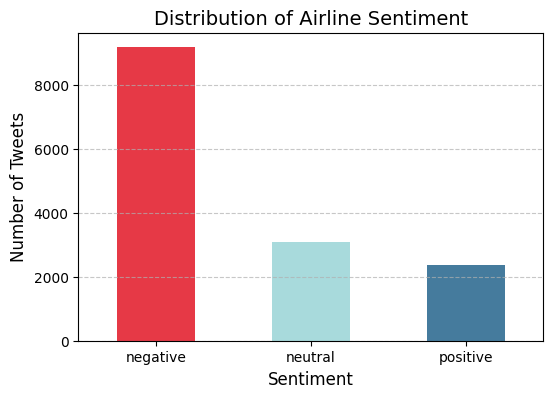

In [9]:
#Exploring Column airline_sentiment

#Understanding values in Column airline_sentiment
unique_airline_sentiment_count = full_df_tweets['airline_sentiment'].nunique()
print('The unique values in Column airline_sentiment are:',unique_airline_sentiment_count)
print(' ')

sentiment_counts = full_df_tweets['airline_sentiment'].value_counts()
#Sorting the counts in descending order
sentiment_counts = sentiment_counts.sort_values(ascending=False)
print(sentiment_counts)
print(' ')

#Plotting a bar chart for sentiment_counts
plt.figure(figsize=(6, 4))
sentiment_counts.plot(kind='bar', color=['#E63946', '#A8DADC', '#457B9D'])

plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.title('Distribution of Airline Sentiment', fontsize=14)
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### Column airline_sentiment_confidence

The unique values in Column airline_sentiment_confidence are: 1023
 
airline_sentiment_confidence
1.0000    10409
0.6667       71
0.6632       35
0.6596       30
0.6559       30
          ...  
0.6938        1
0.7282        1
0.7063        1
0.6979        1
0.6958        1
Name: count, Length: 1023, dtype: int64
 


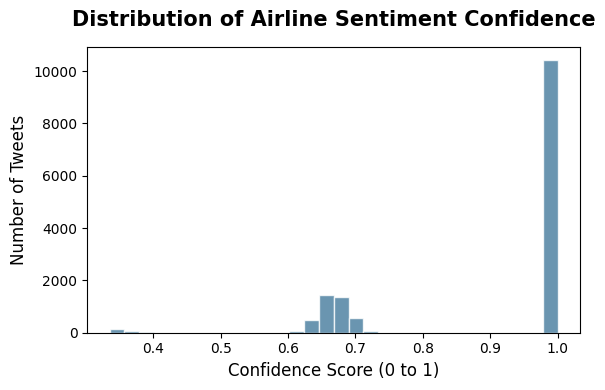

In [10]:
#Exploring Column airline_sentiment_confidence
#left skewed between 0 and 1

#Understanding values in Column airline_sentiment_confidence
unique_airline_sentiment_confidence_count = full_df_tweets['airline_sentiment_confidence'].nunique()
print('The unique values in Column airline_sentiment_confidence are:',unique_airline_sentiment_confidence_count)
print(' ')

sentiment_confidence_counts = full_df_tweets['airline_sentiment_confidence'].value_counts()
#Sorting the counts in descending order
sentiment_confidence_counts = sentiment_confidence_counts.sort_values(ascending=False)
print(sentiment_confidence_counts)
print(' ')

#Defining the data from the airline_sentiment_confidence column
airline_sentiment_confidence_data = full_df_tweets['airline_sentiment_confidence']

#Plotting a histogram
plt.figure(figsize=(6, 4))
plt.hist(airline_sentiment_confidence_data, bins=30, color='#457B9D', edgecolor='white', alpha=0.8)

plt.title('Distribution of Airline Sentiment Confidence', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Confidence Score (0 to 1)', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)

plt.tight_layout()
plt.show()

##### Column negativereason

In [11]:
#Exploring Column negativereason

#Understanding values in Column negativereason
unique_negativereason_count = full_df_tweets['negativereason'].nunique()
print('The unique values in Column negativereason are:', unique_negativereason_count)
print(' ')

negativereason_counts = full_df_tweets['negativereason'].value_counts().sort_values(ascending=False)
#Sorting the counts in descending order
negativereason_counts = negativereason_counts.sort_values(ascending=False)
print('Initial values for negativereason counts:')
print(negativereason_counts)
print(' ')

#Creating a dictionary to map the current long names to new shorter names for plots
short_negativereason = {
    "Customer Service Issue": "Customer Service",
    "Late Flight": "Delay",
    "Can't Tell": "Unknown",
    "Cancelled Flight": "Cancellation",
    "Lost Luggage": "Lost Luggage",
    "Bad Flight": "Flight Quality",
    "Flight Booking Problems": "Booking",
    "Flight Attendant Complaints": "Attendant Complaint",
    "longlines": "Lines",
    "Damaged Luggage": "Damaged Luggage"
}

#Applying the mapping to column negativereason
full_df_tweets['negativereason'] = full_df_tweets['negativereason'].replace(short_negativereason)

#Verifying the changes in column negativereason values
print('Updated values for negativereason counts:')
print(full_df_tweets['negativereason'].value_counts())

The unique values in Column negativereason are: 10
 
Initial values for negativereason counts:
negativereason
Customer Service Issue         2904
Late Flight                    1660
Can't Tell                     1190
Cancelled Flight                843
Lost Luggage                    721
Bad Flight                      580
Flight Booking Problems         529
Flight Attendant Complaints     480
longlines                       178
Damaged Luggage                  74
Name: count, dtype: int64
 
Updated values for negativereason counts:
negativereason
Customer Service       2904
Delay                  1660
Unknown                1190
Cancellation            843
Lost Luggage            721
Flight Quality          580
Booking                 529
Attendant Complaint     480
Lines                   178
Damaged Luggage          74
Name: count, dtype: int64


negativereason
Customer Service       2904
Delay                  1660
Unknown                1190
Cancellation            843
Luggage Issue           795
Flight Quality          580
Booking                 529
Attendant Complaint     480
Lines                   178
Name: count, dtype: int64


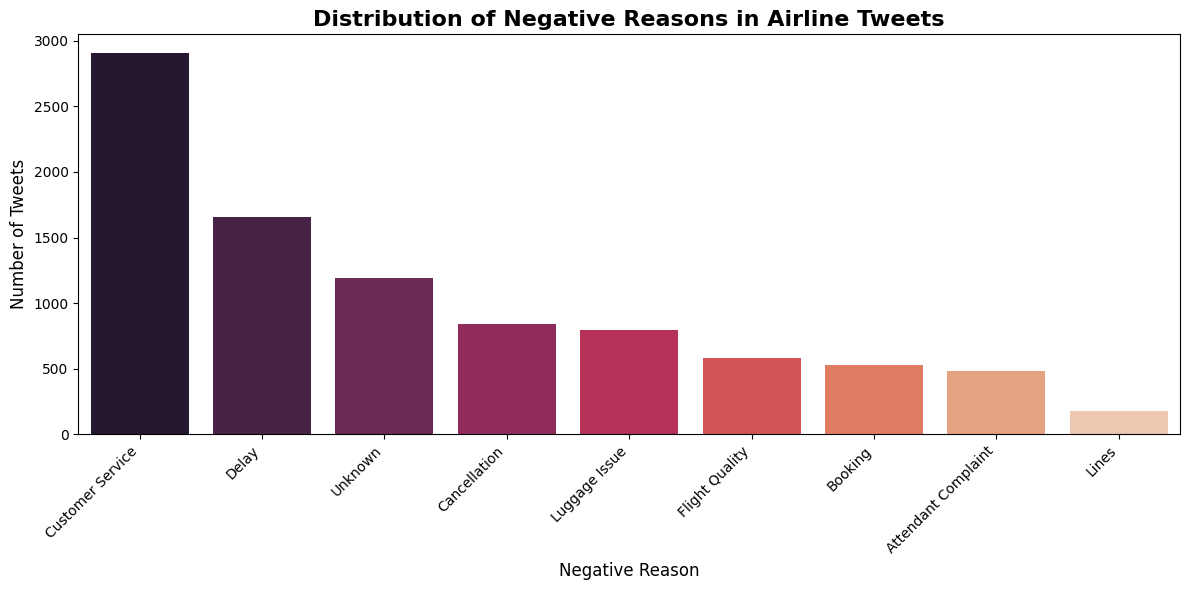

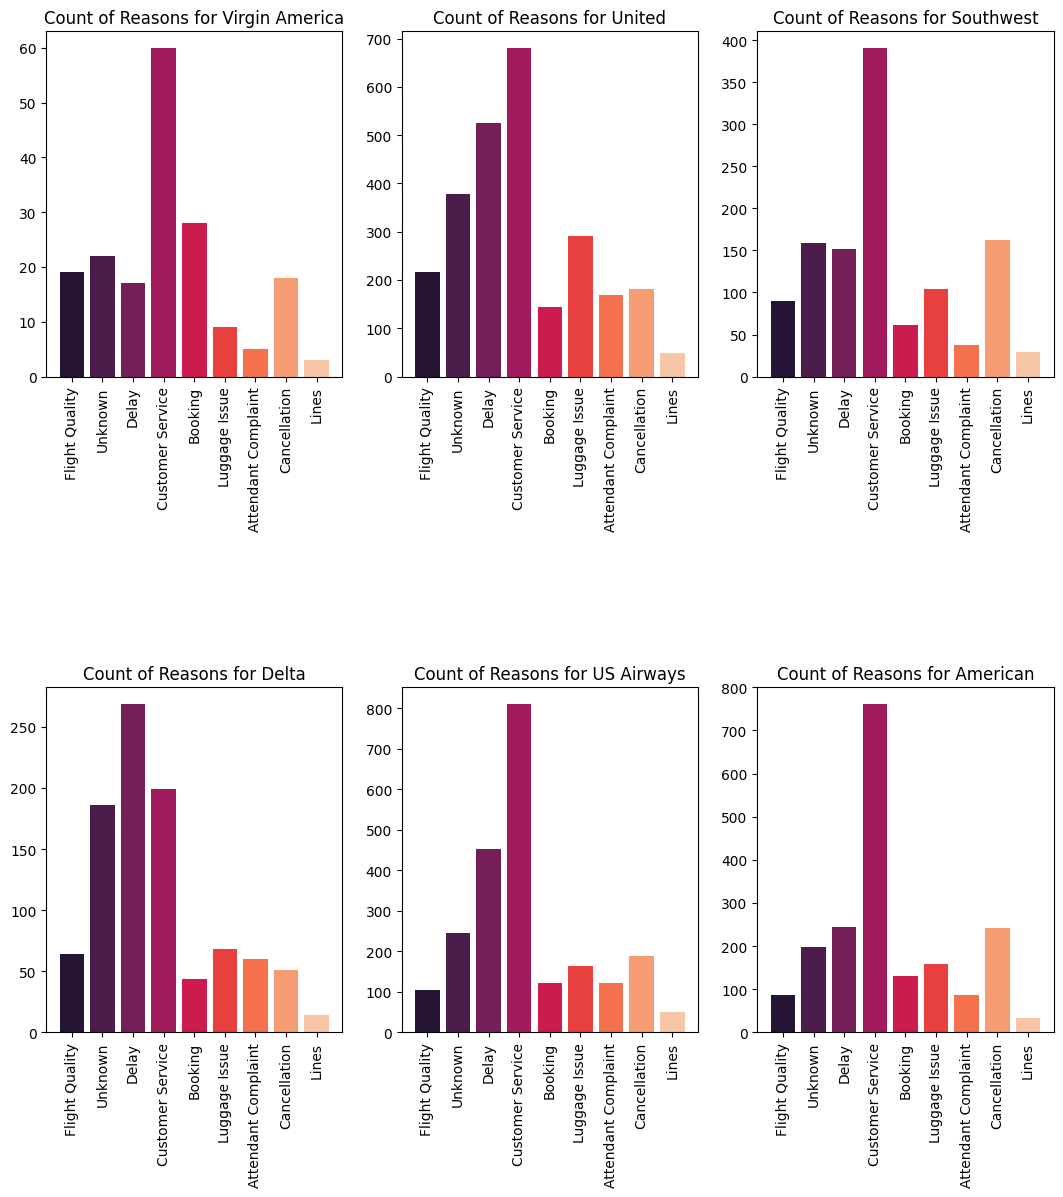

In [12]:
#Creating a dictionary mapping both luggage issues to a single category
luggage_grouping = {"Lost Luggage": "Luggage Issue","Damaged Luggage": "Luggage Issue"}

#Applying the mapping to dataframe
full_df_tweets['negativereason'] = full_df_tweets['negativereason'].replace(luggage_grouping)

#Verifying the changes
print(full_df_tweets['negativereason'].value_counts())

#Getting final negative reason counts after all mapping
final_negativereason_counts = full_df_tweets['negativereason'].value_counts()

#Plotting a barplot
plt.figure(figsize=(12, 6))
sns.barplot(x=final_negativereason_counts.index, y=final_negativereason_counts.values,hue=final_negativereason_counts.index,
            palette="rocket",legend=False)

plt.title('Distribution of Negative Reasons in Airline Tweets', fontsize=16, fontweight='bold')
plt.xlabel('Negative Reason', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

NR_Count = full_df_tweets['negativereason'].value_counts()

def NCount(Airline):
    airlineName = full_df_tweets[full_df_tweets['airline'] == Airline]
    count = airlineName['negativereason'].value_counts()
    Unique_reason = full_df_tweets['negativereason'].unique()
    Unique_reason = [x for x in Unique_reason if str(x) != 'nan']
    Reason_frame = pd.DataFrame({'Reasons': Unique_reason})
    
    #Adding a safeguard in case a reason doesn't exist for an airline to fill with 0
    Reason_frame['count'] = Reason_frame['Reasons'].apply(lambda x: count.get(x, 0))
    return Reason_frame

def plot_reason(airline):
    a = NCount(airline)
    count = a['count']
    Id = range(1, (len(a) + 1))
    
    #Extracting the 'rocket' color palette from Seaborn and pass it to Matplotlib
    colors = sns.color_palette("rocket", len(a))
    
    #Plotting the bars using 'color'
    plt.bar(Id, count, color=colors)
    plt.xticks(Id, a['Reasons'], rotation=90)
    plt.title('Count of Reasons for ' + str(airline))

#Dynamically pulling the unique airlines from your dataframe
airlines = full_df_tweets['airline'].dropna().unique().tolist()

plt.figure(2, figsize=(13, 13))
for i in airlines:
    indices = airlines.index(i)
    plt.subplot(2, 3, indices + 1)
    plt.subplots_adjust(hspace=0.9)
    plot_reason(i)

plt.show()

##### Column airline

The unique values in Column airline are: 6
 
Values for airline counts:
airline
United            3822
US Airways        2913
American          2723
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64
 


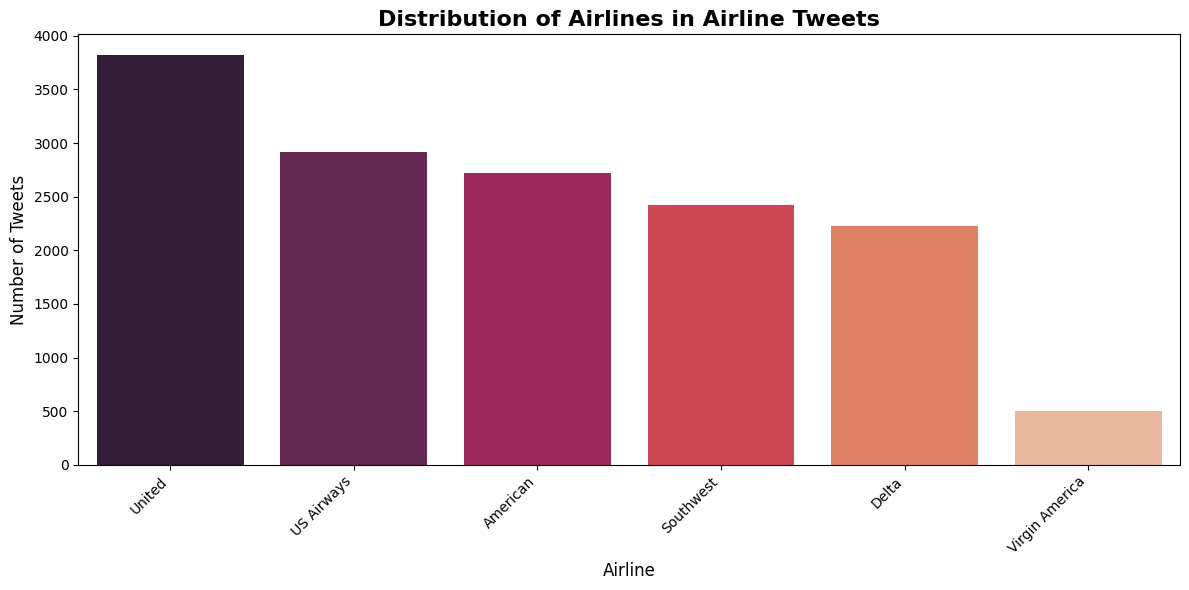

In [13]:
#Exploring Column airline

#Understanding values in Column airline
unique_airline_count = full_df_tweets['airline'].nunique()
print('The unique values in Column airline are:', unique_airline_count)
print(' ')

airline_counts = full_df_tweets['airline'].value_counts().sort_values(ascending=False)
#Sorting the counts in descending order
airline_counts = airline_counts.sort_values(ascending=False)
print('Values for airline counts:')
print(airline_counts)
print(' ')

#Plotting a barplot
plt.figure(figsize=(12, 6))
sns.barplot(x=airline_counts.index, y=airline_counts.values,hue=airline_counts.index,
            palette="rocket",legend=False)

plt.title('Distribution of Airlines in Airline Tweets', fontsize=16, fontweight='bold')
plt.xlabel('Airline', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

##### Column retweet_count

The unique values in Column retweet_count are: 18
 
Values for retweet counts:
retweet_count
0     13838
1       639
2        66
3        22
4        17
5         5
7         3
6         3
22        2
18        1
15        1
31        1
11        1
8         1
9         1
28        1
32        1
44        1
Name: count, dtype: int64
 
count    14604.00
mean         0.08
std          0.75
min          0.00
25%          0.00
50%          0.00
75%          0.00
max         44.00
Name: retweet_count, dtype: float64


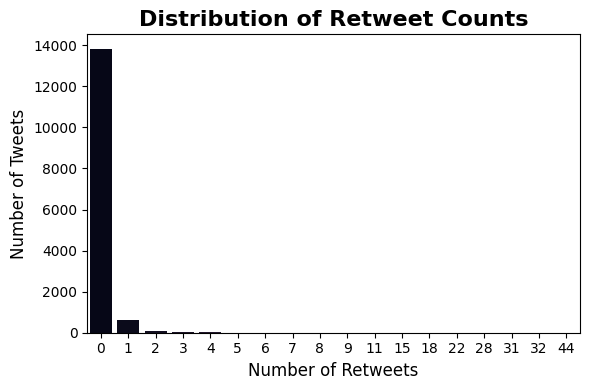

Original Skewness: 33.8772


In [14]:
#Exploring Column retweet_count
#Right Skewed

#Understanding values in Column retweet_count
unique_retweet_count = full_df_tweets['retweet_count'].nunique()
print('The unique values in Column retweet_count are:', unique_retweet_count)
print(' ')

retweet_counts = full_df_tweets['retweet_count'].value_counts().sort_values(ascending=False)
#Sorting the counts in descending order
retweet_counts = retweet_counts.sort_values(ascending=False)
print('Values for retweet counts:')
print(retweet_counts)
print(' ')

#Checking Statistics for Column retweet_count
print(full_df_tweets['retweet_count'].describe().round(2))

#Plotting barplot for the Distribution of Retweet Counts
plt.figure(figsize=(6,4))
sns.barplot(x=retweet_counts.index, y=retweet_counts.values, hue=retweet_counts.index, palette="rocket", legend=False)

plt.title('Distribution of Retweet Counts', fontsize=16, fontweight='bold')
plt.xlabel('Number of Retweets', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)

#Keeping the numbers straight since they are short
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

original_skew = full_df_tweets['retweet_count'].skew()
print(f"Original Skewness: {original_skew:.4f}")

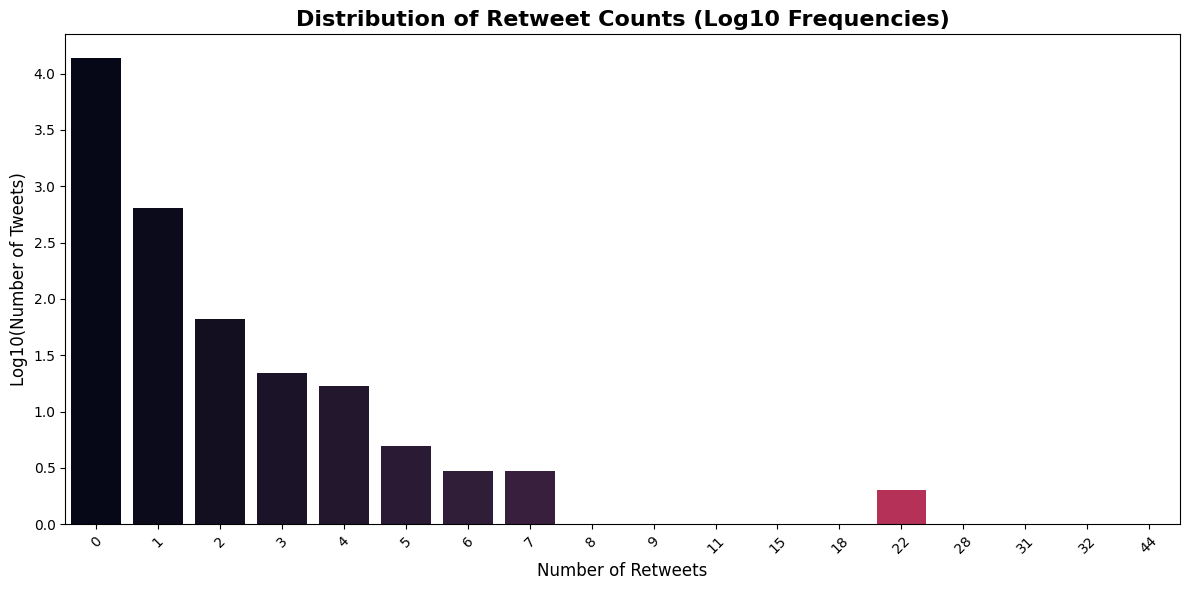

Skewness after Log10 Transformation: 6.3864
 


In [15]:
#Implementing log transformation with np.log10 (due to 0s existing in our values) to the frequencies (y-axis values)
log10_frequencies = np.log10(retweet_counts.values)

plt.figure(figsize=(12, 6))

#Plotting barplot for the Distribution of Retweet Counts after log transformation
sns.barplot(x=retweet_counts.index, y=log10_frequencies, hue=retweet_counts.index, palette="rocket", legend=False);

plt.title('Distribution of Retweet Counts (Log10 Frequencies)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Retweets', fontsize=12)
plt.ylabel('Log10(Number of Tweets)', fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

full_df_tweets['retweet_count_log10'] = np.log10(full_df_tweets['retweet_count'] + 1)
transformed_skew = full_df_tweets['retweet_count_log10'].skew()
print(f"Skewness after Log10 Transformation: {transformed_skew:.4f}")
print(" ")

In [16]:
#Checking updated Statistics for Column retweet_count_log10
print(full_df_tweets['retweet_count_log10'].describe().round(2))
print(' ')

#Checking for Extreme Outliers of column retweet_count_log10

#Creating a list for all values of column retweet_count_log10
extr_retweet_count_log10 = full_df_tweets['retweet_count_log10'].to_list()

#Splitting OverallQual values in percentiles 
Q1 = np.percentile(extr_retweet_count_log10,25,method='midpoint')
Q2 = np.percentile(extr_retweet_count_log10,50,method='midpoint')
Q3 = np.percentile(extr_retweet_count_log10,75,method='midpoint')

#Calculating the Interquartile Range
IQR=Q3-Q1

print('retweet_count_log10 Extreme Outliers are:')
print('Minimum:', Q1 - 3 * IQR)  #lower outlier fence
print('Maximum:', Q3 + 3 * IQR)  #maximum outlier fence
print(' ')
#Most values are 0 so IQR method is not working. Will procced with zscores

#Checking top10 z_scores for extreme outliers 
top_10_z_scores=pd.Series(stats.zscore(full_df_tweets['retweet_count_log10'])).sort_values().tail(10).round(2)
print(top_10_z_scores)
print(' ')

#Checking more thorougly from value counts for outliers 6<=retweet_count<=45
outliers_to_remove = full_df_tweets.query('6 <= retweet_count <= 45').index

print(f"Number of rows identified for removal: {len(outliers_to_remove)}")
print(f"Row Indexes being dropped: {list(outliers_to_remove)}")

#Dropping outliers found 
full_df_tweets = full_df_tweets.drop(index=outliers_to_remove)

#Reseting index of DataFrame
full_df_tweets.reset_index(drop=True, inplace=True)

#Re-calculating the log column since the data changed
full_df_tweets['retweet_count_log10'] = np.log10(full_df_tweets['retweet_count'] + 1)

#Verifying the results
print('Updated Shape:', full_df_tweets.shape)
print('Top Retweet Counts remaining:')
print(full_df_tweets['retweet_count'].value_counts().sort_index(ascending=False))

count    14604.00
mean         0.02
std          0.09
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          1.65
Name: retweet_count_log10, dtype: float64
 
retweet_count_log10 Extreme Outliers are:
Minimum: 0.0
Maximum: 0.0
 
9453     11.25
7453     12.16
7111     13.59
7027     14.45
7115     15.40
5607     15.40
9999     16.56
7132     17.05
11582    17.20
11596    18.74
dtype: float64
 
Number of rows identified for removal: 17
Row Indexes being dropped: [4144, 5270, 5607, 6969, 7027, 7032, 7111, 7115, 7132, 7134, 7453, 8438, 8444, 9453, 9999, 11582, 11596]
Updated Shape: (14587, 8)
Top Retweet Counts remaining:
retweet_count
5        5
4       17
3       22
2       66
1      639
0    13838
Name: count, dtype: int64


count    14587.00
mean         0.02
std          0.08
min          0.00
25%          0.00
50%          0.00
75%          0.00
max          0.78
Name: retweet_count_log10, dtype: float64
 


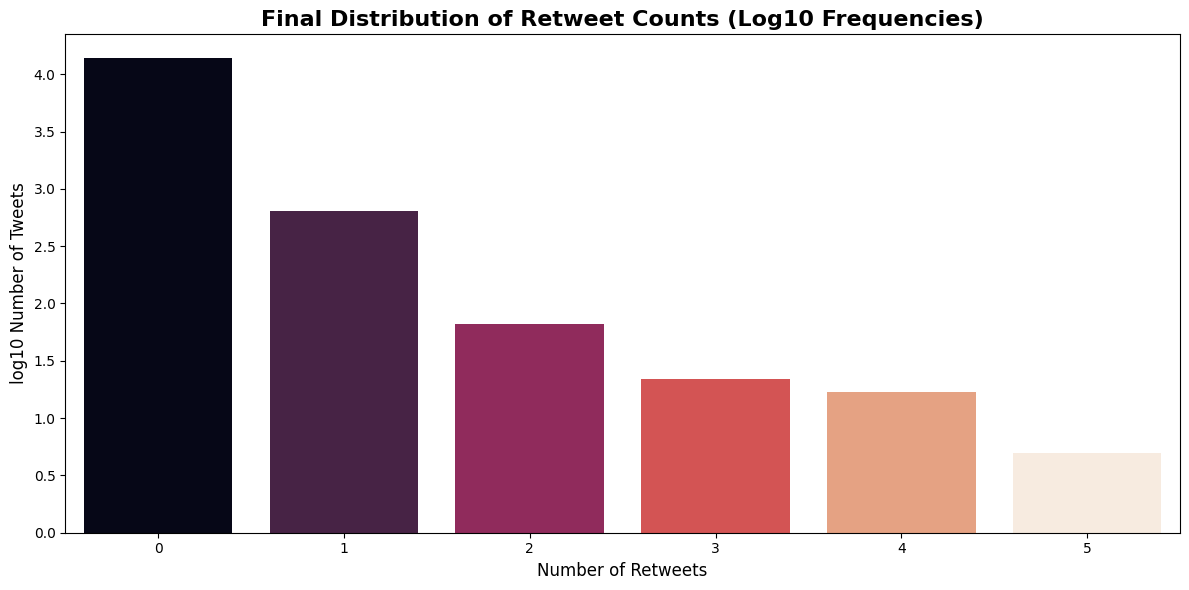

Final Skewness after Outlier Removal: 4.8285


In [17]:
#Checking updated Statistics for Column retweet_count_log10
print(full_df_tweets['retweet_count_log10'].describe().round(2))
print(' ')

#Re-calculating retweet counts for the updated dataframe
retweet_counts_updated = full_df_tweets['retweet_count'].value_counts().sort_index()

#Re-calculating the log10 frequencies for the Y-axis
log10_frequencies_updated = np.log10(retweet_counts_updated.values)

#Plotting the updated barplot
plt.figure(figsize=(12, 6))

sns.barplot(
    x=retweet_counts_updated.index, 
    y=log10_frequencies_updated, 
    hue=retweet_counts_updated.index, 
    palette="rocket", 
    legend=False
)

plt.title('Final Distribution of Retweet Counts (Log10 Frequencies)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Retweets', fontsize=12)
plt.ylabel('log10 Number of Tweets', fontsize=12)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

#Final Skewness Check for column retweet_count_log10
final_skew = full_df_tweets['retweet_count_log10'].skew()
print(f"Final Skewness after Outlier Removal: {final_skew:.4f}")

##### Column tweet_created

The unique values in Column tweet_created are: 14230
 


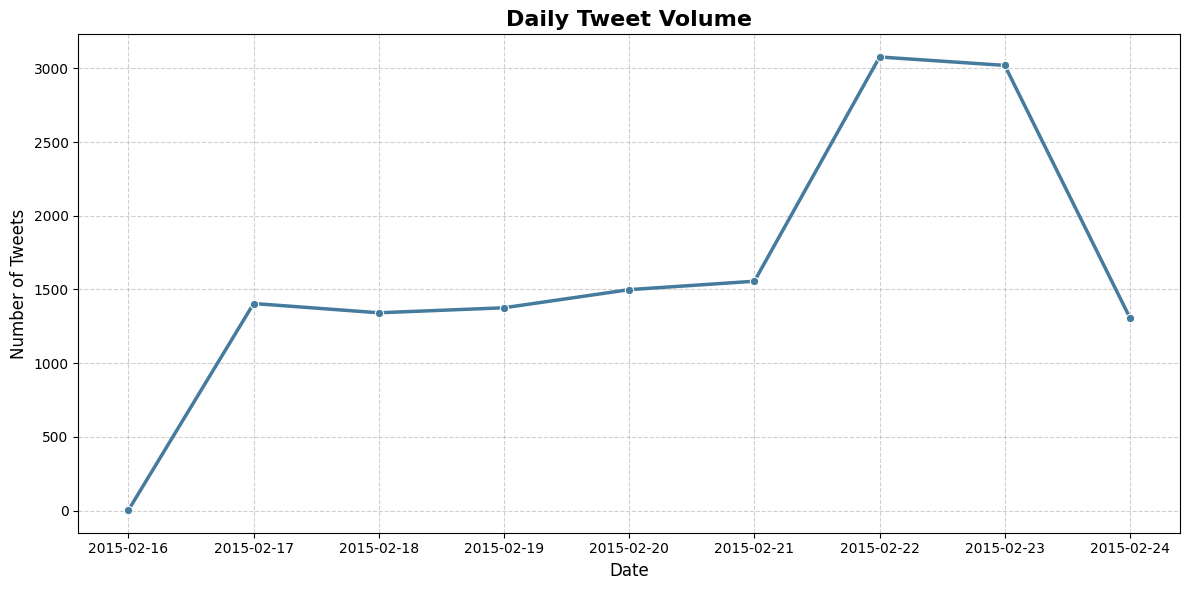

In [18]:
#Exploring Column tweet_created

#Understanding values in Column retweet_count
unique_tweet_created = full_df_tweets['tweet_created'].nunique()
print('The unique values in Column tweet_created are:', unique_tweet_created)
print(' ')

#Converting the column tweet_created to actual datetime objects
full_df_tweets['tweet_created'] = pd.to_datetime(full_df_tweets['tweet_created'])

#Extracting just the Date (YYYY-MM-DD) to group the tweets per day
full_df_tweets['tweet_date'] = full_df_tweets['tweet_created'].dt.date

#Counting tweets per day
daily_counts = full_df_tweets['tweet_date'].value_counts().sort_index()

#Plotting as a Line Chart to show tweets trends over time
plt.figure(figsize=(12, 6))
sns.lineplot(x=daily_counts.index, y=daily_counts.values, marker='o', color='#457B9D', linewidth=2.5)

plt.title('Daily Tweet Volume', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

##### Main column text / raw corpus

In [19]:
#Exploring Column text

#Understanding values in Column text
unique_text_count = full_df_tweets['text'].nunique()
print('The unique values in Feature Column text are:',unique_text_count)
print(' ')

df_text_tweets = full_df_tweets[["text"]].copy()
df_text_tweets["text"] = df_text_tweets["text"].astype(str)

#Creating the corpus 
corpus=df_text_tweets["text"]

The unique values in Feature Column text are: 14410
 


###### Visualizing character tweet Count (raw corpus)

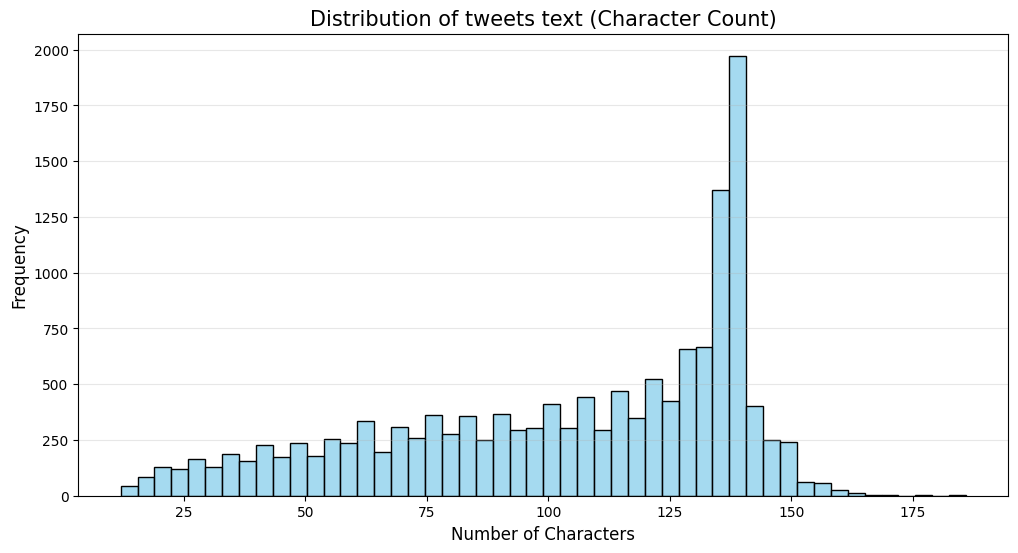

In [20]:
#Checking the number of characters present in each sentence to have a rough idea about the text headline length
#Calculating sentence lengths
df_text_tweets["char_count"] = df_text_tweets["text"].str.len()

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df_text_tweets["char_count"], bins=50, color="skyblue")
plt.title("Distribution of tweets text (Character Count)", fontsize=15)
plt.xlabel("Number of Characters", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

###### Visualizing Word tweet Count (raw corpus)

Mean Word Count: 18.00
Median Word Count: 19.00


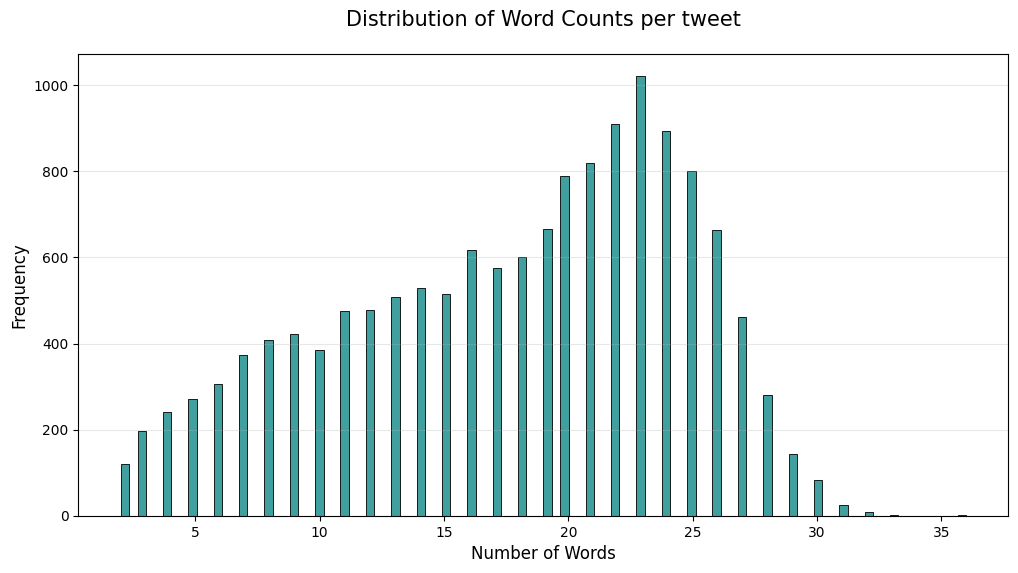

In [21]:
#Calculating word counts by splitting strings into lists
df_text_tweets["word_count"] = df_text_tweets["text"].str.split().str.len()

#Calculating key statistics
mean_words = df_text_tweets["word_count"].mean().round()
median_words = df_text_tweets["word_count"].median().round()

print(f"Mean Word Count: {mean_words:.2f}")
print(f"Median Word Count: {median_words:.2f}")

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df_text_tweets["word_count"], bins=100, color="teal", label="Word Count")

plt.title("Distribution of Word Counts per tweet", fontsize=15, pad=20)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

###### Visualizing average tweet word length (raw corpus)

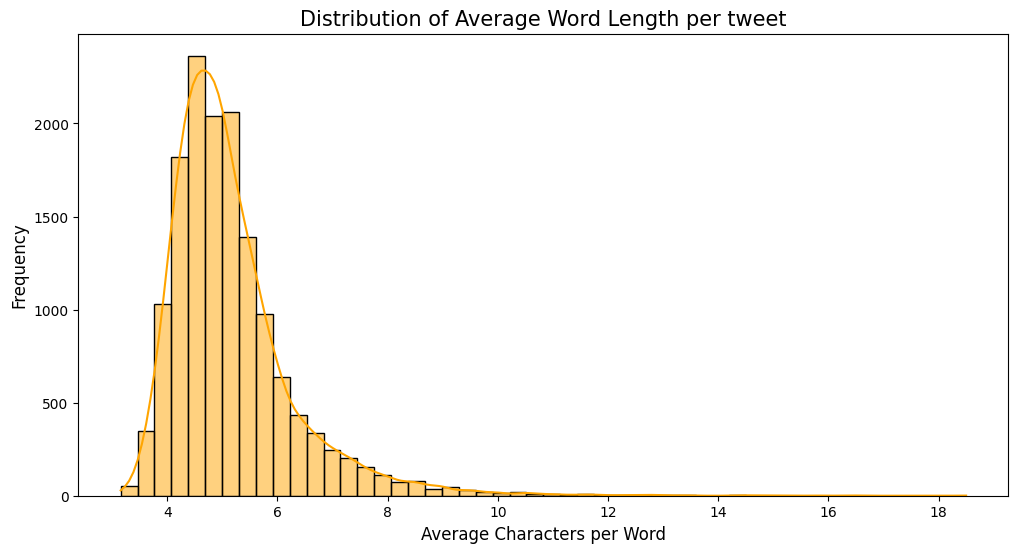

In [22]:
def get_avg_word_len(text):
    """Function to calculate average word length"""
    words = str(text).split()
    if len(words) == 0:
        return 0
    return sum(len(word) for word in words) / len(words)

df_text_tweets['avg_word_len'] = df_text_tweets['text'].apply(get_avg_word_len)

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df_text_tweets['avg_word_len'], bins=50, kde=True, color="orange")

plt.title("Distribution of Average Word Length per tweet", fontsize=15)
plt.xlabel("Average Characters per Word", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

###### Ngram exploration (Raw) for column text

In [23]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngram(corpus, n=1):
    vec = CountVectorizer(ngram_range=(n, n), stop_words=None).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    
    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vec.vocabulary_.items()]
    
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:10]

#Initializing the raw corpus
corpus = df_text_tweets["text"]

#Extracting the top 10 for different n-gram ranges
top_unigrams = get_top_ngram(corpus, n=1)
top_bigrams = get_top_ngram(corpus, n=2)
top_trigrams = get_top_ngram(corpus, n=3)

print("Top 10 Unigrams (Raw):", top_unigrams)
print("Top 10 Bigrams (Raw):", top_bigrams)
print("Top 10 Trigrams (Raw):", top_trigrams)

Top 10 Unigrams (Raw): [('to', np.int64(8635)), ('the', np.int64(6048)), ('you', np.int64(4384)), ('united', np.int64(4163)), ('for', np.int64(3987)), ('flight', np.int64(3928)), ('on', np.int64(3790)), ('and', np.int64(3723)), ('my', np.int64(3273)), ('usairways', np.int64(3049))]
Top 10 Bigrams (Raw): [('http co', np.int64(1142)), ('thank you', np.int64(566)), ('customer service', np.int64(560)), ('on the', np.int64(545)), ('on hold', np.int64(514)), ('cancelled flightled', np.int64(504)), ('to get', np.int64(482)), ('my flight', np.int64(479)), ('for the', np.int64(455)), ('thanks for', np.int64(393))]
Top 10 Trigrams (Raw): [('on hold for', np.int64(237)), ('been on hold', np.int64(166)), ('thank you for', np.int64(145)), ('thanks for the', np.int64(144)), ('fleet on fleek', np.int64(139)), ('jetblue our fleet', np.int64(138)), ('our fleet on', np.int64(138)), ('on fleek http', np.int64(136)), ('fleek http co', np.int64(136)), ('was cancelled flightled', np.int64(105))]


###### Visualizing Top 10 Unigrams (Raw) for column text

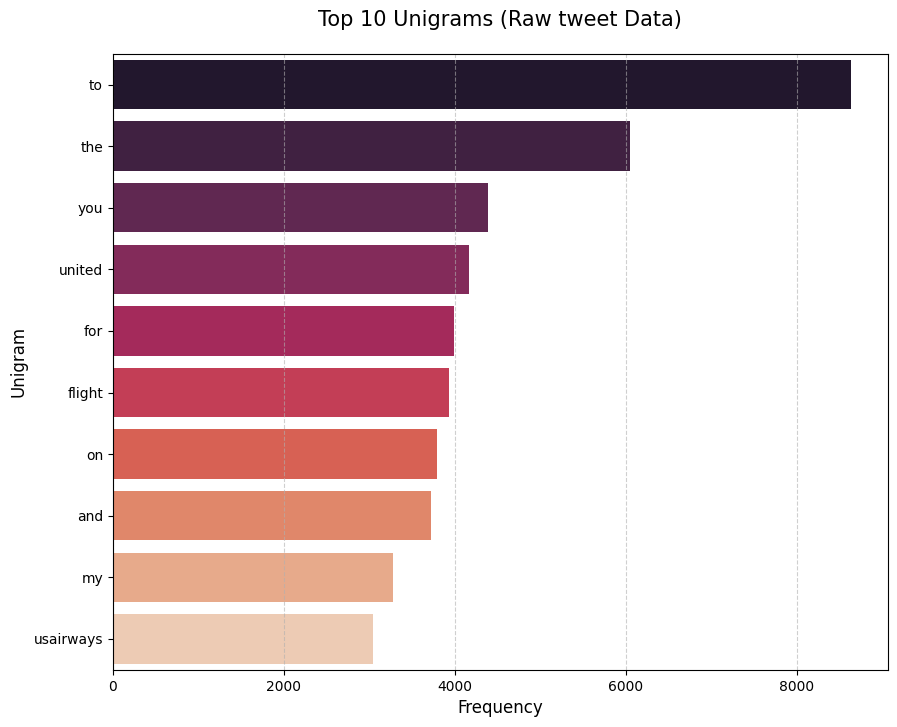

In [24]:
#Unzipping the list of tuples into two separate lists
words, counts = zip(*top_unigrams)

#Visualizing Top 10 Bigrams for the raw corpus
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="rocket", legend=False);

plt.title("Top 10 Unigrams (Raw tweet Data)", fontsize=15, pad=20)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Unigram", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

###### Visualizing Top 10 Bigrams (Raw) for column text

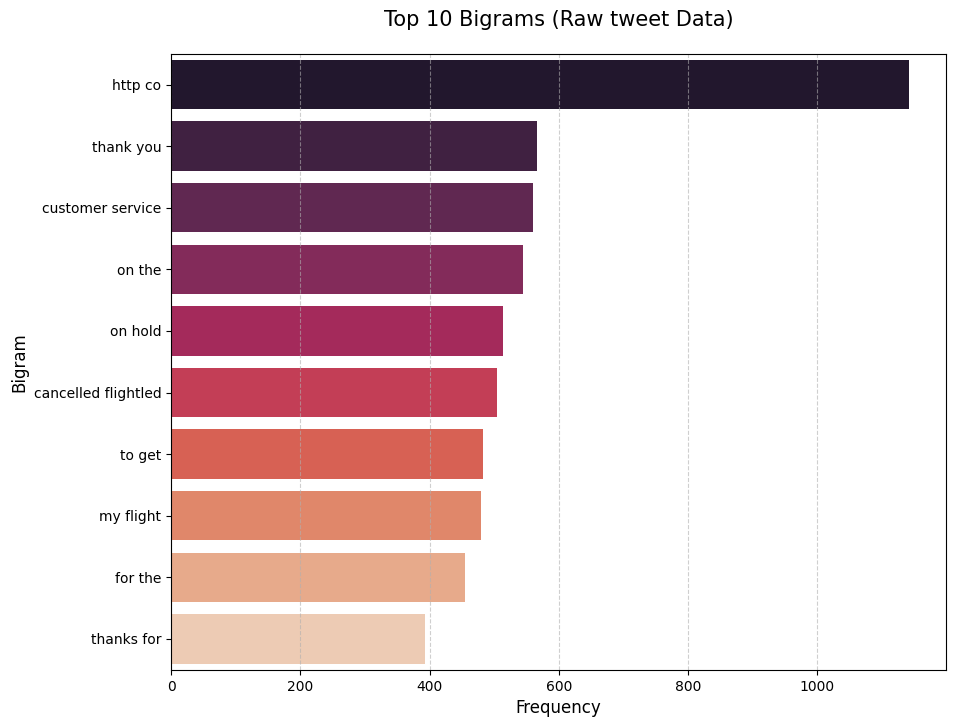

In [25]:
#Unzipping the list of tuples into two separate lists
words, counts = zip(*top_bigrams)

#Visualizing Top 10 Bigrams for the raw corpus
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="rocket", legend=False);

plt.title("Top 10 Bigrams (Raw tweet Data)", fontsize=15, pad=20)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Bigram", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

###### Visualizing Top 10 Trigrams (Raw) for column text

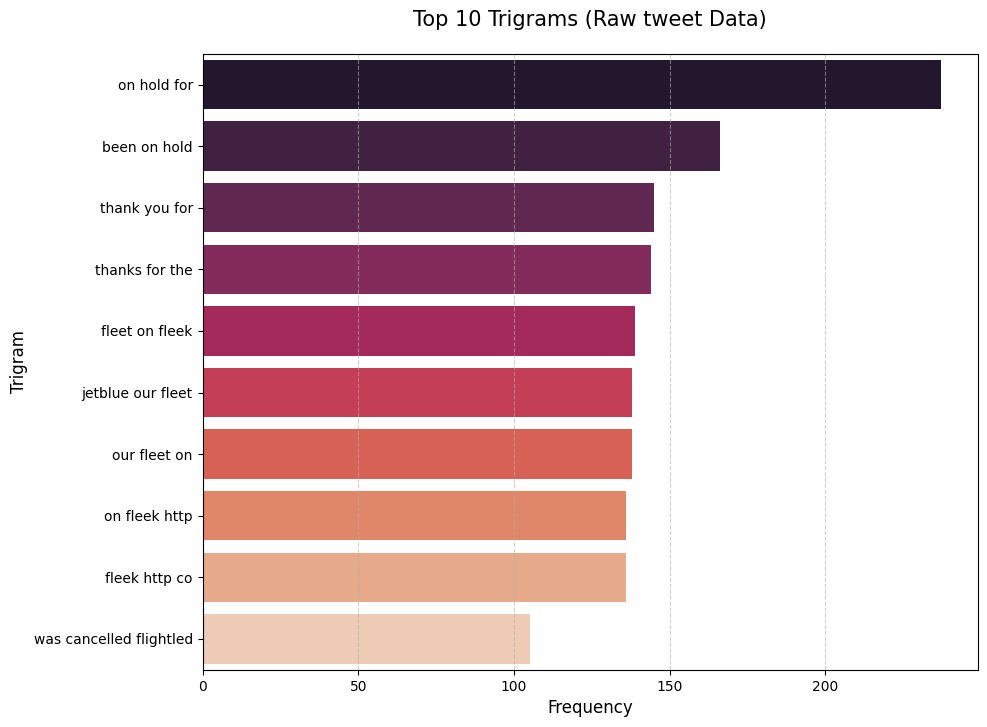

In [26]:
#Unzipping the list of tuples into two separate lists
words, counts = zip(*top_trigrams)

#Visualizing Top 10 Bigrams for the raw corpus
plt.figure(figsize=(10, 8))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="rocket", legend=False);

plt.title("Top 10 Trigrams (Raw tweet Data)", fontsize=15, pad=20)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Trigram", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

###### Topic modeling exploration (Raw) for column text

In [27]:
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import pyLDAvis.lda_model

#Vectorizing the raw corpus
raw_corpus = df_text_tweets["text"]
tf_vectorizer = CountVectorizer(stop_words=None)
tf = tf_vectorizer.fit_transform(raw_corpus)

#Initializing and fitting LDA for n_components=6
lda_model = LatentDirichletAllocation(n_components=6, random_state=42)
lda_model.fit(tf)

#Preparing the visualization
panel = pyLDAvis.lda_model.prepare(lda_model, tf, tf_vectorizer, mds='tsne')

#Displaying the dashboard
pyLDAvis.enable_notebook()
pyLDAvis.display(panel)

##### Cleaning column text

###### Removal of HTML Tags like <'p> or <br'> of column text

In [28]:
from bs4 import BeautifulSoup

def remove_html_tags(text):
    """
    Removes HTML tags using BeautifulSoup. 
    If no tags are present, it returns the original text intact.
    """
    #checking to handle NaN/None or non-string values
    if pd.isna(text) or not isinstance(text, str):
        return text
        
    #Parsing the text and extracting only the string content
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text(separator=" ", strip=True)

df_text_tweets["text_no_html"] = df_text_tweets["text"].apply(remove_html_tags)

#Updating corpus
corpus=df_text_tweets["text_no_html"]

###### Removal of urls in the cleaned from html tags text column

In [29]:
import re

def remove_urls(text):
    """
    Removes URLs from the text using regular expressions.
    If no URLs are present, it returns the original previous text intact.
    """
    #Checking to handle NaN/None or non-string values
    if pd.isna(text) or not isinstance(text, str):
        return text
        
    #Regex pattern to match http, https, and www URLs
    url_pattern = re.compile(r'http[s]?://\S+|www\.\S+|\S+\.com\b|\S+\.net\b|\S+\.org\b')
    
    #Replacing the matched URLs with an empty string
    return url_pattern.sub(r'', text)

#Applying the URL removal to the text that just had HTML removed
df_text_tweets["text_no_url"] = df_text_tweets["text_no_html"].apply(remove_urls)

#Updating corpus
corpus=df_text_tweets["text_no_url"]

###### Removal of Emoticons like :-) & translating them into text in till now cleaned text rows

In [30]:
import re

#Creating a dictionary of common emoticons and their text translations
EMOTICON_DICT = {
    r':-\)': ' happy ', r':\)': ' happy ', r':-\]': ' happy ', r':\]': ' happy ',
    r':-\(': ' sad ', r':\(': ' sad ', r':-\[': ' sad ', r':\[': ' sad ',
    r':-D': ' laugh ', r':D': ' laugh ', r'XD': ' laugh ',
    r';-\)': ' wink ', r';\)': ' wink ',
    r':-P': ' playful ', r':P': ' playful '
}

def translate_emoticons(text):
    """Translates ASCII emoticons to words BEFORE punctuation is removed"""
    text = str(text)
    for emoticon, word in EMOTICON_DICT.items():
        text = re.sub(emoticon, word, text, flags=re.IGNORECASE)
    return text

#Applying this to the raw text :
df_text_tweets["after_emoticons_translation_text"] = df_text_tweets["text_no_url"].apply(translate_emoticons)

#Updating corpus
corpus=df_text_tweets["after_emoticons_translation_text"]

###### Removal of Emojis like 😀 & translating them into text in till now cleaned text rows

In [31]:
import emoji

def translate_emoji_to_words(text):
    """Translates emojis into text aliases (e.g., 👍 becomes 'thumbs up')"""
    translated_text = emoji.demojize(str(text), delimiters=(" ", " "))
    
    #Replacing underscores with spaces so 'thumbs_up' for example becomes 'thumbs up'
    translated_text = translated_text.replace("_", " ")
    
    return translated_text

#Applying it to the latest cleaned text column
df_text_tweets["after_emojis_emoticons_translation_text"] = df_text_tweets["after_emoticons_translation_text"].apply(translate_emoji_to_words)

#Cleaning up any extra whitespace left behind
df_text_tweets["after_emojis_emoticons_translation_text"] = df_text_tweets["after_emojis_emoticons_translation_text"].str.replace(r'\s+', ' ', regex=True).str.strip()

#Updating corpus
corpus=df_text_tweets["after_emojis_emoticons_translation_text"]

#display(df_text_tweets.head())
#print(' ')
#display(df_text_tweets.sample())
#print(' ')
#display(df_text_tweets.tail())

###### Removal of # in till now cleaned text rows

In [32]:
#Removing # symbol
df_text_tweets["after_#_emojis_emoticons_translation_text"] = (
    df_text_tweets["after_emojis_emoticons_translation_text"]
    .str.replace('#', ' ', regex=False)       # Space instead of empty string
    .str.replace(r'\s+', ' ', regex=True)     # Collapse double spaces
    .str.strip()
)

#In case wanted to remove all #hashtag
#df_text_tweets["after_#_emojis_emoticons_translation_text"] = (
#    df_text_tweets["after_emojis_emoticons_translation_text"]
#    .str.replace(r'#\w+', ' ', regex=True)    #Removing #word completely
#    .str.replace(r'\s+', ' ', regex=True)    #Cleaning extra whitespace
#    .str.strip()                             #Removing leading/trailing spaces
#)

#Updating corpus
corpus=df_text_tweets["after_#_emojis_emoticons_translation_text"]

#Checking updated corpus
df_text_tweets["after_#_emojis_emoticons_translation_text"].sample(15)

12450                                                                      @AmericanAir lovely flight back from MIA to LHR - great crew - thanks happy )
4285     @united @jsumiyasu I am thankful to the United ground staff who put me in the last seat on the last flight out. Home Late Flight is still home!
3881                                                                                               @united did not get names...Dallas flight and Chicago
6974                                                                @JetBlue hi guys, do you have a general enquires email address please? Thanks David.
5136                                            @SouthwestAir How do I retroactively add previous flights/miles/points to current rapid rewards balance?
11609    @USAirways delayed my flight 3 times before Cancelled Flighting it, had angry and rude workers, and are now providing no helpful service at all
9958              @USAirways 2nd plane forced to get off due to mech and wait for 

###### Removal of @ in till now cleaned text rows

In [33]:
#Removing @ symbol 
df_text_tweets["after_@_#_emojis_emoticons_translation_text"] = (
    df_text_tweets["after_#_emojis_emoticons_translation_text"]  
    .str.replace('@', ' ', regex=False)         # Removing @ symbol
    .str.replace(r'\s+', ' ', regex=True)       # Cleaning extra whitespace
    .str.strip()                                # Removing leading/trailing spaces
)

#Removing @username completely in case wanted
#df_text_tweets["after_@_#_emojis_emoticons_translation_text"] = (
#    df_text_tweets["after_#_emojis_emoticons_translation_text"]
#    .str.replace(r'@\w+', ' ', regex=True)       # Removing @username completely
#    .str.replace(r'\s+', ' ', regex=True)       # Cleaning extra whitespace
#    .str.strip()                                # Removing leading/trailing spaces
#)

#Updating corpus
corpus=df_text_tweets["after_@_#_emojis_emoticons_translation_text"]

#Checking updated corpus
df_text_tweets["after_@_#_emojis_emoticons_translation_text"].sample(15)

12297    AmericanAir I know this is probably a no but is there a way to get a cheaper airfare ticket if the flight is leaving in a few hours? folded hands
4082                           united FYI: continuous texts and emails I am getting about the delay while held captive on the tarmac are not that helpful.
10798                           USAirways Just talked to reservation. Must congratulation to them. Very friendly. Good for usair. The ONLY airline we fly.
1404            united Not to belabor my point,but shouldn't I be able to put a laptop bag above my seat? Why is it announced to leave it for rollers? Thx
12630                                                                                   AmericanAir I've just received the ticket. Thank you for your help
11750                             USAirways flight 1808 is not leaving at 2:45 because we haven't even begun to board yet. Please update your website ASAP
9072           USAirways been on hold for 2 hours for something which 

###### Implementing lower case in till now cleaned text rows

In [34]:
df_text_tweets["after_lower_@_#_emojis_emoticons_translation_text"] = (
    df_text_tweets["after_@_#_emojis_emoticons_translation_text"]
    .str.lower()                                #Converting to lowercase
    .str.replace(r'\s+', ' ', regex=True)       #Cleaning extra whitespace
    .str.strip()                                #Removing leading/trailing spaces
)

#Updating corpus
corpus=df_text_tweets["after_lower_@_#_emojis_emoticons_translation_text"]

#Checking updated corpus
df_text_tweets["after_lower_@_#_emojis_emoticons_translation_text"].sample(15)

13226                                                                                                               americanair don't see response!
5499                        southwestair we had early bird, and it was great. your employees were awesome. it was 3 passengers who killed the buzz.
7718     jetblue disappointed with the missed connection from roc to slc and no reimbursement even tho friend who is a pilot said it was due to atc
10564        usairways - thanks for the 5+ hour flight from pit to phx with zero entertainment. guess why i have a quarter million + miles on delta
782                                                                                                                  united is my favorite airline.
4552        southwestair when i called i was told my bag had made it to phl, but still has not been delivered or any call from the delivery service
13989                                                                              americanair the bags arent ev

###### Removing punctuation , .  (no removal of ! ?) in till now cleaned text rows

In [35]:
#Removing punctuation but keeping ! and ? as these are important for sentiment analysis
df_text_tweets["after_punct_lower_@_#_emojis_emoticons_translation_text"] = (
    df_text_tweets["after_lower_@_#_emojis_emoticons_translation_text"]
    .str.replace(r'[^\w\s!?]', '', regex=True)   #Removing punctuation but keeping ! and ?
    .str.replace(r'\s+', ' ', regex=True)        #Cleaning extra whitespace
    .str.strip()                                 #Removing leading/trailing spaces
) 

#Updating corpus
corpus=df_text_tweets["after_punct_lower_@_#_emojis_emoticons_translation_text"]

#Checking updated corpus
df_text_tweets["after_punct_lower_@_#_emojis_emoticons_translation_text"].sample(15)

8773                                                                                          jetblue ticket issued whilst delivering your customers
2063                                          united you sure missed the mark on tonights redeye from lax to chicago what a mess! you can do better!
5880                                              southwestair presceo gary kelly at therofo addressing 2000 of his bwi based employees cbsbaltimore
12765            americanair i bought a plane ticket 2 months ago and still havent received my flight info and ticket in my email when it will come?
1643                                                                                united once again your lack of customer centricity us astounding
3923     united pgatour ntrustopen i read that last hashtag as go f united makes sense since they f us by cancelled flightling ticketed reservations
12820                                       americanair first ride on new 737800 with new interior and in 

###### Removing digits in till now cleaned text rows

In [36]:
#Removing digits
df_text_tweets["after_digits_punct_lower_@_#_emojis_emoticons_translation_text"] = (
    df_text_tweets["after_punct_lower_@_#_emojis_emoticons_translation_text"]
    .str.replace(r'\d+', '', regex=True)         #Removing digits
    .str.replace(r'\s+', ' ', regex=True)        #Cleaning extra whitespace
    .str.strip()                                 #Removing leading/trailing spaces
)

#Updating corpus
corpus=df_text_tweets["after_digits_punct_lower_@_#_emojis_emoticons_translation_text"]

#Checking updated corpus
df_text_tweets["after_digits_punct_lower_@_#_emojis_emoticons_translation_text"].sample(15)

6101                      southwestair looks like on february we will open our schedule for sale through october know what time that will be?
13468     americanair called last night after hrs got call back can i get a one day pass to admirals club? im going to be spending hrs in dfw
13768                                                                                               americanair nope i have not been rebooked
12184                                                                             americanair well have all day and all the time in the world
11511                                                usairways now over hrs cant wait anymore hrs for nothing now what?? frustrated usairways
465                                                                                virginamerica i love the dancing little richard cool beans
6312                        southwestair in my letters to follow i will be sure to include my rewards number twitter handle and email address
6489  

###### Removing stopwords (not the negation words) in till now cleaned text rows

In [37]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

#Defining stopwords and keeping negation words
stop_words = set(stopwords.words('english'))

negation_words = {"no", "not", "nor", "never", "neither", "nobody", "nothing",
                  "nowhere", "don't", "doesn't", "didn't", "won't", "wouldn't",
                  "couldn't", "shouldn't", "isn't", "aren't", "wasn't", "weren't",
                  "hasn't", "haven't", "hadn't", "can't", "cannot","dont","cant"}

#Removing negation words from stopwords list
stop_words = stop_words - negation_words

#Removing stopwords
df_text_tweets["after_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"] = (
    df_text_tweets["after_digits_punct_lower_@_#_emojis_emoticons_translation_text"]
    .apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))
    .str.replace(r'\s+', ' ', regex=True)        # Cleaning extra whitespace
    .str.strip()                                 # Removing leading/trailing spaces
)

#Updating corpus
corpus=df_text_tweets["after_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"]

#Checking updated corpus
display(df_text_tweets["after_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].sample(15))
#print(' ')
#display(df_text_tweets["after_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].head(15))
#print(' ')
#display(df_text_tweets["after_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].tail(15))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\roxan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


7468                                                                                     jetblue fly jet blue
12175                                                                           americanair um south snow atl
1539                                                 united hour min delay far would love round hours go bed!
1814                united im not sure help flight experience terrible planes dirty staff rude start perhaps?
13532                  americanair school trip including sleep airport different standby flightsthis not good
8739                                   jetblue supervisor humiliated us uncompromising completely blindsided!
8885              jetblue learning famous apology social media marketing twitter asset jet blue now? phd mama
3602                                                                             united okay thank help happy
438                                                                      virginamerica miss nerdbird san jose
6240      

###### Removal of Chat Words & translating them into text in till now cleaned text rows

In [38]:
import re

SENTIMENT_CHAT_WORDS_DICT = {
    "a3":"anytime anywhere anyplace","afaik":"as far as i know","afk":"away from keyboard","aka":"also known as",
    "approx":"approximately","asap":"as soon as possible","atk":"at the keyboard","atm":"at the moment",
    "b4n":"bye for now","bak":"back at keyboard","bbl":"be back later","bbs":"be back soon","bfn":"bye for now",
    "brb":"be right back","brt":"be right there","btw":"by the way","b/c":"because","cu":"see you",
    "cul8r":"see you later","cya":"see you","dm":"direct message","eod":"end of day","eow":"end of week",
    "eta":"estimated time of arrival","faq":"frequently asked questions","fwiw":"for what its worth","fyp":"for you page",
    "fyi":"for your information","gal":"get a life","gmta":"great minds think alike","hbu":"how about you","ic":"i see",
    "icq":"i seek you","iirc":"if i recall correctly","iow":"in other words","irl":"in real life","iykyk":"if you know you know",
    "l8r":"later","ldr":"long distance relationship","lmk":"let me know","ltns":"long time no see","m8":"mate","mfw":"my face when",
    "mrw":"my reaction when","mte":"my thoughts exactly","nrn":"no reply necessary","oic":"oh i see","ootl":"out of the loop",
    "pov":"point of view","prt":"party","pls":"please","plz":"please","prw":"parents are watching","rn":"right now","tba":"to be announced",
    "tbd":"to be determined","tbf":"to be fair","tfw":"that feeling when","thx":"thank you","ttfn":"ta ta for now","ttyl":"talk to you later",
    "u2":"you too","u4e":"yours for ever","w/":"with","w/o":"without","wb":"welcome back","wbu":"what about you","wuf":"where are you from",
    "wtg":"way to go","wyd":"what you doing","wywh":"wish you were here","ik":"i know","sk8":"skate","bae":"before anyone else",
    "nvm":"never mind","tbh":"to be honest","tldr":"too long did not read","tntl":"trying not to laugh","adih":"another day in hell",
    "ngl":"not going to lie","periodt":"and that is final","ikr":"i agree completely","vibe":"atmosphere","tea":"gossip",
    "clout":"social influence","receipts":"evidence","flexing":"showing off","simp":"overly devoted person","stan":"devoted fan",
    "it's giving":"it resembles","no tea no shade":"not trying to offend","lol":"amused","haha":"amused","hehe":"amused",
    "lmao":"laughing hysterically","lmfao":"laughing hysterically","rofl":"laughing hysterically","roflol":"laughing hysterically",
    "rotflmao":"laughing hysterically","bwl":"laughing hysterically","csl":"laughing","jk":"just kidding","/s":"sarcastic",                    
    "nah":"no disagree","/j":"joking","/lh":"lighthearted","/srs":"serious","/pos":"positive intent","/neg":"negative intent",
    "af":"extremely","asf":"extremely","deadass":"seriously","fr fr":"very seriously","fr":"for real","lowkey":"somewhat",
    "highkey":"very much","no cap":"seriously","wtf":"outraged","fml":"my life is terrible","idgaf":"i do not care at all",
    "smh":"shaking my head in disappointment","smfh":"extremely disappointed","ffs":"for crying out loud","istg":"i swear to god",
    "pita":"annoying","oof":"that is unfortunate","yikes":"that is alarming","pressed":"upset and bothered","triggered":"offended",
    "salty":"bitter and upset","shade":"subtle disrespect","trash":"terrible","garbage":"terrible","flop":"failure",
    "cope":"denial of reality","seethe":"be angry about it","problematic":"offensive behavior","toxic":"harmful behavior",
    "clout chasing":"seeking attention insincerely","dragged":"publicly criticized","ratio":"post was widely rejected","cooked":"in serious trouble",
    "mid":"mediocre","sus":"suspicious","cringe":"embarrassing","cap":"lie","npc":"boring unoriginal person","unhinged":"erratic behavior",
    "villain era":"embracing selfish behavior","touch grass":"disconnected from reality","rent free":"obsessively thinking about",
    "chronically online":"too absorbed in internet culture","caught in 4k":"caught red-handed","community noted":"publicly fact checked and wrong",
    "l take":"bad opinion","ghosted":"ignored and rejected","shook":"shocked and disturbed","not okay":"distressed","gr8":"great","g9":"genius",
    "gn":"good night","goat":"greatest of all time","goated":"greatest of all time","gg":"well played","fc":"fingers crossed",
    "bsaaw":"big smile and a wink","blessed":"grateful and happy","thriving":"doing very well","lit":"exciting and excellent","elite":"top quality",
    "valid":"acceptable and good","drip":"stylish appearance","vibing":"feeling relaxed and happy","slaps":"is excellent",
    "iconic":"remarkably impressive","slay":"performed impressively","bussin":"delicious and amazing","based":"admirable and correct",
    "rizz":"natural charisma","glow up":"impressive self improvement","hits different":"feels uniquely special",
    "understood the assignment": "performed perfectly","fimh":"forever in my heart","hbd":"happy birthday","idc":"i do not care",
    "idk":"i do not know","ifyp":"i feel your pain","ilu":"i love you","ily":"i love you","imu":"i miss you","imho":"in my humble opinion",
    "imo":"in my opinion","omg":"oh my god","omfg":"oh my god incredibly shocked","fomo":"fear of missing out","woke":"socially aware",
}

def apply_chat_dict(text: str, chat_dict: dict = SENTIMENT_CHAT_WORDS_DICT) -> str:
    """
    Replaces chat abbreviations in text using word-boundary-safe regex.
    - Lowercases input before matching
    - Sorts keys by length descending so longer matches win (e.g. 'fr fr' before 'fr')
    - Uses word boundaries to prevent substring corruption
    """
    text = text.lower()
    sorted_keys = sorted(chat_dict.keys(), key=len, reverse=True)
    for key in sorted_keys:
        #Escaping special regex chars in key (e.g. "w/" contains "/")
        escaped_key = re.escape(key)
        pattern = r'\b' + escaped_key + r'\b'
        text = re.sub(pattern, chat_dict[key], text)
    return text

#Applying chat words translation
df_text_tweets["after_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"] = (
    df_text_tweets["after_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"]
    .apply(lambda x: apply_chat_dict(x, SENTIMENT_CHAT_WORDS_DICT))
    .str.replace(r'\s+', ' ', regex=True)        #Cleaning extra whitespace
    .str.strip()                                 #Removing leading/trailing spaces
)

#Updating corpus
corpus=df_text_tweets["after_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"]

#Checking updated corpus
display(df_text_tweets["after_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].sample(15))
#print(' ')
#display(df_text_tweets["after_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].head(15))
#print(' ')
#display(df_text_tweets["after_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].tail(15))

2336                                             united forced check rollaboard ua ? plenty room overhead next seat
3900                        united leisure military personnel safety reason r highly recommended not travel uniform
1938                                                                                                   united thank
6160                                  southwestair weve lost whole day honeymoon disappointed frustrated everything
3310                         united looking back never heard anyone call frankly got standard sop still think today
11360                                                                   usairways us wife boston says no snow right
6250                                               southwestair kirkwoodtiger hmmm caribbean sound? ld warm thanks!
12161                        americanair trying change time flight already purchased told pay change fee ridiculous
1300                                                                    

###### Checking for remaining stopwords not properly cleaned in till now cleaned text rows

In [39]:
from nltk.corpus import stopwords

stop_words = stop_words - negation_words

#Checking remaining stopwords in corpus
def find_remaining_stopwords(text):
    words = text.split()
    return [word for word in words if word in stop_words]

remaining = df_text_tweets["after_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].apply(find_remaining_stopwords)

from collections import Counter
all_remaining = [word for sublist in remaining for word in sublist]
stopword_counts = Counter(all_remaining)

print(f"Total remaining stopword instances: {sum(stopword_counts.values())}")
print(f"Unique remaining stopwords: {len(stopword_counts)}")
print("Top 20 remaining stopwords:")
print(stopword_counts.most_common(20))

Total remaining stopword instances: 408
Unique remaining stopwords: 24
Top 20 remaining stopwords:
[('as', 89), ('you', 86), ('my', 40), ('and', 36), ('by', 24), ('the', 24), ('for', 23), ('in', 22), ('your', 18), ('of', 9), ('before', 6), ('i', 5), ('that', 4), ('do', 4), ('is', 3), ('now', 3), ('what', 2), ('its', 2), ('when', 2), ('a', 2)]


###### Second pass on stopwords removal to clean reintroduced stopwords from chat word expansion in till now cleaned text rows

In [40]:
df_text_tweets["after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"] = (
    df_text_tweets["after_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"]
    .apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))
    .str.replace(r'\s+', ' ', regex=True)        #Cleaning extra whitespace
    .str.strip()                                 #Removing leading/trailing spaces
)

#Updating corpus
corpus=df_text_tweets["after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"]

#Checking updated corpus
display(df_text_tweets["after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].sample(15))
#print(' ')
#display(df_text_tweets["after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].head(15))
#print(' ')
#display(df_text_tweets["after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].tail(15))


#Verifying no stopwords remain (should be None)
remaining = df_text_tweets["after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].apply(find_remaining_stopwords)
all_remaining = [word for sublist in remaining for word in sublist]
print(' ')
print(f"Remaining stopwords after second pass to clean reintroduced stopwords from chat word expansion: {len(all_remaining)}")

4452                                                                                                    southwestair ok thank hope
12034                                americanair new time confirmed may get cancelled flightled? traveling kids need certain thank
10055                                                         usairways british airways three hour flight delay phone min counting
7756                                             jetblue sure hope guys get dc speak tomorrow! johnnosta united im winning jetblue
5827                                                                                              southwestair direct message sent
1140                                                                          united really know piss people farelock option fake!
9347                                  usairways friend telling gate attendant stewardess going notourfaultyoudontuseyourgatesright
8993                                 usairways standing gate min trying go standby 

 
Remaining stopwords after second pass to clean reintroduced stopwords from chat word expansion: 0


###### Dropping not needed any more columns in dataframe

In [41]:
df_text_tweets.drop(["char_count","word_count","avg_word_len", "text_no_html","text_no_url","after_emoticons_translation_text",
                    "after_emojis_emoticons_translation_text","after_#_emojis_emoticons_translation_text", 
                    "after_@_#_emojis_emoticons_translation_text","after_lower_@_#_emojis_emoticons_translation_text",
                     "after_punct_lower_@_#_emojis_emoticons_translation_text",
                     "after_digits_punct_lower_@_#_emojis_emoticons_translation_text",
                     "after_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text",
                     "after_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"
                     ],axis=1, inplace=True, errors='ignore')

#Checking at the moment columns
display(df_text_tweets.head())
#print(' ')
#display(df_text_tweets.sample(5))
#print(' ')
#display(df_text_tweets.tail())

,text,after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text
0,@VirginAmerica What @dhepburn said.,virginamerica dhepburn said
1,@VirginAmerica plus you've added commercials to the experience... tacky.,virginamerica plus youve added commercials experience tacky
2,@VirginAmerica I didn't today... Must mean I need to take another trip!,virginamerica didnt today must mean need take another trip!
3,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",virginamerica really aggressive blast obnoxious entertainment guests faces little recourse
4,@VirginAmerica and it's a really big bad thing about it,virginamerica really big bad thing


###### Most Frequent words check in till now cleaned text rows

In [42]:
top_50_words = df_text_tweets["after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].str.split().explode().value_counts().head(50)
print(top_50_words)

after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text
united           4142
flight           3737
usairways        3044
americanair      2918
southwestair     2450
jetblue          2340
not              1537
no               1473
get              1335
cancelled        1049
thanks            877
service           873
im                762
customer          741
time              714
thank             706
us                682
help              654
hours             628
hold              616
flights           608
please            589
cant              575
plane             574
still             566
need              552
would             547
one               546
virginamerica     522
delayed           500
gate              499
dont              498
back              485
call              483
flightled         467
hour              463
got               459
face              452
bag               436
like              426
late              424
phone     

###### Inserting custom words in the stopwords & removing them from till now cleaned text rows

In [43]:
from nltk.corpus import stopwords

#Defining negation words to keep
negation_words = {"no", "not", "nor", "never", "neither", "nobody", "nothing",
                  "nowhere", "don't", "doesn't", "didn't", "won't", "wouldn't",
                  "couldn't", "shouldn't", "isn't", "aren't", "wasn't", "weren't",
                  "hasn't", "haven't", "hadn't", "can't", "cannot","dont","cant"}

#Defining custom filler words
custom_words_to_ignore = {"im", "us", "flightled", "got", "one", "way", "guys", "like", "face","ive","fleek","fleets","rt","folded","hands",
                         "get", "go", "make", "say", "take","would", "still", "back","thats", "youre","try","give","flightr","reflight",
                         "flighted","tear","joy","smile","eye","aa", "flt", "min", "pm", "hr","dm","ba","ill", "ua", "bg", "dont", "tomorrow", "last",
                          "long", "show", "send", "new","bo", "night", "happen", "online", "first", "crew","flight", "flights", "airline", "plane",
                          "thank", "thanks","americanair","united","usairways","southwestair","jetblue","virginamerica","yvr", "yyz", "zrh", 
                          "lax", "jfk", "ord", "atl","zurich", "yvonne", "zkatcher","yow", "yrs", "yuma", "youve", "aacom",
                          "aafail","aadvantage","aadv","abcnetwork","youyou","yousuck","youll","youareonyourown", "youd", "youi", "abq",
                         "aal", "aano", "aarp", "aas", "york","abt", "yest","loudly", "cry","yesso","dcabos"}    

#Building the final stopwords set using only NLTK
stop_words = set(stopwords.words('english'))   #NLTK base stopwords
stop_words.update(custom_words_to_ignore)      #Adding custom words
stop_words = stop_words - negation_words       #Removing negation words

exceptions_to_keep = {"!", "?", "!!", "??"}.union(negation_words)
#Creating an upgraded cleaning function
def remove_stopwords_and_numbers(text):
    cleaned_words = []
    for word in str(text).split():
        if word in stop_words:
            continue
        if len(word) <= 1 and word not in exceptions_to_keep:  
            continue
        if not word.isalpha() and word not in exceptions_to_keep:  
            continue
        cleaned_words.append(word)
    return " ".join(cleaned_words)

#Applying the upgraded function
df_text_tweets["after_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"] = (
    df_text_tweets["after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"]
    .apply(remove_stopwords_and_numbers)
)

#Updating corpus
corpus = df_text_tweets["after_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"]
print("Text successfully re-cleaned! Numbers, mixed junk, and custom stopwords removed.")

Text successfully re-cleaned! Numbers, mixed junk, and custom stopwords removed.


###### Most Frequent words 2nd check in till now cleaned text rows

In [44]:
top_50_words = df_text_tweets["after_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].str.split().explode().value_counts().head(50)
print(top_50_words)

after_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text
not          1537
no           1473
cancelled    1049
service       873
customer      741
time          714
help          654
hours         628
hold          616
please        589
cant          575
need          552
delayed       500
gate          499
dont          498
call          483
hour          463
bag           436
late          424
phone         403
fly           363
waiting       355
know          353
trying        348
today         340
direct        333
airport       333
going         322
never         316
great         309
flying        308
wait          307
day           305
change        301
message       301
good          296
hrs           294
even          289
minutes       284
weather       283
delay         279
people        272
happy         269
another       268
told          267
want          266
check         264
home          260
see           257
seat          255
Name:

###### Removal of Rare words in till now cleaned text rows

In [45]:
from collections import Counter

#Defining cnt, meaning the counting word frequencies from corpus
cnt = Counter()
for text in df_text_tweets["after_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"]:
    for word in str(text).split():
        cnt[word] += 1

print(f"Total unique words in corpus: {len(cnt)}")

#Defining the min_freq_threshold for removal of words appearing fewer than X times
min_freq_threshold = 2

#Identifying all words that don't meet the threshold
RAREWORDS = set([word for word, count in cnt.items() if count < min_freq_threshold])
print(f"Number of unique rare words to remove: {len(RAREWORDS)}")
print(f"Sample of words appearing only once (to be removed):")
for word in list(RAREWORDS)[:20]:
    print(f"{word}: {cnt[word]}")

#Defining the cleaning function
def remove_rarewords(text):
    """Removes words that appear fewer than the threshold frequency"""
    if pd.isna(text) or not isinstance(text, str):
        return text
    return " ".join([word for word in text.split() if word not in RAREWORDS])

df_text_tweets["after_rare_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"] = df_text_tweets["after_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].apply(remove_rarewords)

#Updating corpus 
corpus=df_text_tweets["after_rare_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"]

#display(df_text_tweets.head())

Total unique words in corpus: 12704
Number of unique rare words to remove: 7101
Sample of words appearing only once (to be removed):
williams: 1
davidson: 1
johns: 1
donedeal: 1
mountains: 1
gardening: 1
albertbreer: 1
quitting: 1
dishonest: 1
sportsbiz: 1
xxx: 1
hurts: 1
sux: 1
genuinely: 1
wakinginmemphis: 1
unitedexcited: 1
thewayoftheidhaa: 1
contracts: 1
telleveryone: 1
naders: 1


###### Lemmatization in till now cleaned text rows

In [46]:
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

#Downloading the required wordnet data & POS tagger model
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)

lemmatizer = WordNetLemmatizer()

#Mapping nltk POS tags to WordNet POS tags
wordnet_map = {"N": wordnet.NOUN, "V": wordnet.VERB, "J": wordnet.ADJ, "R": wordnet.ADV}

airline_names = {"united", "usairways", "americanair", "southwestair", "jetblue", "virginamerica"}

def lemmatize_words(text):
    pos_tagged_text = nltk.pos_tag(str(text).split())
    return " ".join([
        word if word in airline_names else  #Protecting airline names
        lemmatizer.lemmatize(word, wordnet_map.get(pos[0], wordnet.NOUN)) 
        for word, pos in pos_tagged_text
    ])

df_text_tweets["lemmatized_cleaned_text"] = df_text_tweets["after_rare_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text"].apply(lambda text: lemmatize_words(text))

#Updating corpus
corpus=df_text_tweets["lemmatized_cleaned_text"]

display(df_text_tweets[["after_rare_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text", "lemmatized_cleaned_text"]].head())
#print(' ')
#display(df_text_tweets[["after_rare_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text", "lemmatized_cleaned_text"]].sample(5))
#print(' ')
#display(df_text_tweets[["after_rare_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text", "lemmatized_cleaned_text"]].tail())

,after_rare_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text,lemmatized_cleaned_text
0,said,say
1,plus added commercials experience,plus added commercial experience
2,didnt today must mean need another,didnt today must mean need another
3,really aggressive blast obnoxious entertainment guests faces little recourse,really aggressive blast obnoxious entertainment guest face little recourse
4,really big bad thing,really big bad thing


###### Most Frequent words 3rd check in till now cleaned text rows

In [47]:
top_50_words = corpus.str.split().explode().value_counts().head(50)
print(top_50_words)

lemmatized_cleaned_text
not         1537
no          1473
hour        1091
cancel       987
customer     914
service      903
time         880
delay        852
call         740
help         738
fly          728
wait         708
hold         680
need         678
bag          675
please       589
cant         575
gate         522
day          515
dont         498
seat         476
try          450
book         448
go           444
change       442
tell         440
know         433
phone        427
late         424
check        413
agent        399
say          389
miss         384
make         371
work         368
ticket       366
bad          364
good         361
today        355
airport      354
direct       340
minute       339
leave        328
want         326
well         324
travel       319
message      317
never        316
great        313
see          309
Name: count, dtype: int64


###### Checking Nulls of final cleaned column "lemmatized_cleaned_text" & dropping cleaned text null rows

In [48]:
#Checking for null values
null_count = df_text_tweets["lemmatized_cleaned_text"].isna().sum()
print(f"Number of null values in finally cleaned text column : {null_count}")

#Initial rows before dropping null values
print(f"Rows before dropping null values in finally cleaned text column: {len(df_text_tweets)}")

#Drupping null values
df_text_tweets.dropna(subset=["lemmatized_cleaned_text"], inplace=True)

#Rows after dropping null values and before dropping duplicate values
print(f"Rows after dropping null values and before dropping duplicate values in finally cleaned text column: {len(df_text_tweets)}")

#Keeping only rows where the cleaned text of column "lemmatized_cleaned_text" has length greater than 0
df_text_tweets = df_text_tweets[df_text_tweets["lemmatized_cleaned_text"].str.strip() != ""]

#Final rows after removing empty rows in the cleaned text column "lemmatized_cleaned_text"
print(f"Rows after removing empty rows in finally cleaned text column: {len(df_text_tweets)}")

#Updating corpus
corpus=df_text_tweets["lemmatized_cleaned_text"]

Number of null values in finally cleaned text column : 0
Rows before dropping null values in finally cleaned text column: 14587
Rows after dropping null values and before dropping duplicate values in finally cleaned text column: 14587
Rows after removing empty rows in finally cleaned text column: 14254


###### Third pass on stopwords removal to clean reintroduced stopwords from lemmatization in till now cleaned text rows

In [49]:
df_text_tweets["lemmatized_cleaned_text_final"] = (
    df_text_tweets["lemmatized_cleaned_text"]
    .apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))
    .str.replace(r'\s+', ' ', regex=True)        #Cleaning extra whitespace
    .str.strip()                                 #Removing leading/trailing spaces
)

#Updating corpus
corpus=df_text_tweets["lemmatized_cleaned_text_final"]

#Checking updated corpus
display(df_text_tweets["lemmatized_cleaned_text_final"].sample(15))
#print(' ')
#display(df_text_tweets["lemmatized_cleaned_text_final"].head(15))
#print(' ')
#display(df_text_tweets["lemmatized_cleaned_text_final"].tail(15))


#Verifying no stopwords remain (should be None)
remaining = df_text_tweets["lemmatized_cleaned_text_final"].apply(find_remaining_stopwords)
all_remaining = [word for sublist in remaining for word in sublist]
print(' ')
print(f"Remaining stopwords after second pass to clean reintroduced stopwords from chat word expansion: {len(all_remaining)}")

5903                                                        yes act together
6734                              allow passenger gate agent nothing yo scar
1943                                      let board fly shouldhaveflowndelta
5336                                                                greeting
1614                           suck delay didnt even let know unitedairlines
11598                           not impress feel lot good fly upgraded class
11811                                 hundred people line less half desk clt
14382                      complete ask issue nothing suppose sort situation
8093                                  hope appear leave nearby terminal gate
13758                                      dont care cowboycerrone screw ups
12551    well clear custom auh need iah arrive dfw possible retrieve luggage
4652                                                                    sick
7201         communicate directly customer experience executive joanna email

 
Remaining stopwords after second pass to clean reintroduced stopwords from chat word expansion: 0


###### Removing consecutive duplicate words found in till now cleaned text rows

In [50]:
#Merging punctuation with the negation words to create a master "keep" list
exceptions_to_keep = {"!", "?", "!!", "??"}.union(negation_words)

#Function for removing consecutive duplicate words and filter out 1-2 character words, while protecting
#critical negation words and specific punctuation:

def clean_and_filter_text(text):
    """
    Removes consecutive duplicate words and filters out 1-2 character words,
    protecting critical negation words and specific punctuation.
    """
    words = str(text).split()
    result = []
    
    for i, word in enumerate(words):
        #Skipping consecutive duplicates
        if i > 0 and word == words[i-1]:
            continue
            
        #Skipping 1-2 character words EXCEPT if they are in our protected list
        if len(word) <= 2 and word not in exceptions_to_keep:
            continue
            
        result.append(word)
        
    return " ".join(result)

#Applying the function to the dataframe
df_text_tweets["lemmatized_cleaned_text_final"] = (
    df_text_tweets["lemmatized_cleaned_text_final"]
    .apply(clean_and_filter_text)
    .str.replace(r'\s+', ' ', regex=True) #Cleaning any double spaces
    .str.strip()
)

#Checking for null values
null_count = df_text_tweets["lemmatized_cleaned_text_final"].isna().sum()
print(f"Number of null values in finally cleaned text column : {null_count}")

#Keeping only rows where the cleaned text of column "lemmatized_cleaned_text_final" has length greater than 0
df_text_tweets = df_text_tweets[df_text_tweets["lemmatized_cleaned_text_final"].str.strip() != ""]

#Updating corpus
corpus = df_text_tweets["lemmatized_cleaned_text_final"]

Number of null values in finally cleaned text column : 0


###### Most Frequent words 4th check in till now cleaned text rows

In [51]:
top_50_words = corpus.str.split().explode().value_counts().head(50)
print(top_50_words)

lemmatized_cleaned_text_final
not         1530
no          1461
hour        1082
cancel       984
customer     913
service      901
time         873
delay        845
help         736
call         735
fly          725
wait         705
hold         679
need         677
bag          672
please       576
cant         574
gate         518
day          511
dont         498
seat         473
book         447
change       439
tell         438
know         433
phone        425
late         422
check        412
agent        398
miss         384
work         368
ticket       366
good         361
bad          360
airport      354
today        354
direct       340
minute       339
leave        326
want         325
well         323
travel       319
never        316
message      316
see          308
great        306
even         304
lose         301
sit          295
problem      286
Name: count, dtype: int64


###### Ngram exploration for till now cleaned corpus

In [52]:
#Extracting the top 10 for cleaned n-gram ranges
top_unigrams_clean = get_top_ngram(corpus, n=1)
top_bigrams_clean = get_top_ngram(corpus, n=2)
top_trigrams_clean = get_top_ngram(corpus, n=3)

#Printing the results to see the shift in content
print("Top 10 Cleaned Unigrams:", top_unigrams_clean)
print("Top 10 Cleaned Bigrams:", top_bigrams_clean)
print("Top 10 Cleaned Trigrams:", top_trigrams_clean)

Top 10 Cleaned Unigrams: [('not', np.int64(1530)), ('no', np.int64(1461)), ('hour', np.int64(1082)), ('cancel', np.int64(984)), ('customer', np.int64(913)), ('service', np.int64(901)), ('time', np.int64(873)), ('delay', np.int64(845)), ('help', np.int64(736)), ('call', np.int64(735))]
Top 10 Cleaned Bigrams: [('customer service', np.int64(511)), ('direct message', np.int64(238)), ('hold hour', np.int64(122)), ('book problem', np.int64(110)), ('gate agent', np.int64(109)), ('miss connection', np.int64(83)), ('please help', np.int64(78)), ('hour late', np.int64(74)), ('hour delay', np.int64(72)), ('check bag', np.int64(67))]
Top 10 Cleaned Trigrams: [('follow direct message', np.int64(28)), ('worst customer service', np.int64(27)), ('poor customer service', np.int64(23)), ('sent direct message', np.int64(22)), ('bad customer service', np.int64(20)), ('call customer service', np.int64(20)), ('shake head disappointment', np.int64(19)), ('customer service rep', np.int64(18)), ('great custom

###### Visualizing Top 10 Unigrams for till now cleaned corpus

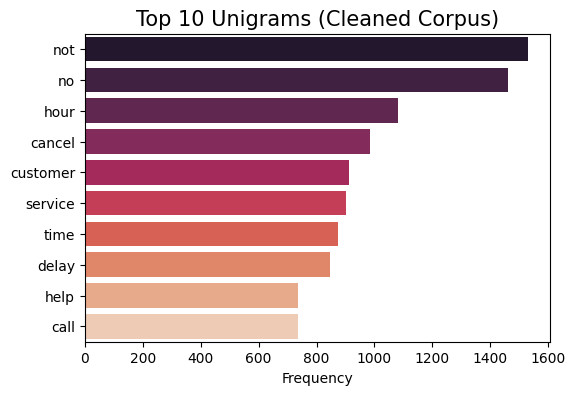

In [53]:
#Plotting Top 10 final cleaned corpus Unigrams
words, counts = zip(*top_unigrams_clean)
plt.figure(figsize=(6, 4))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="rocket", legend=False)
plt.title("Top 10 Unigrams (Cleaned Corpus)", fontsize=15)
plt.xlabel("Frequency")
plt.show()

###### Visualizing Top 10 Bigrams for till now cleaned corpus

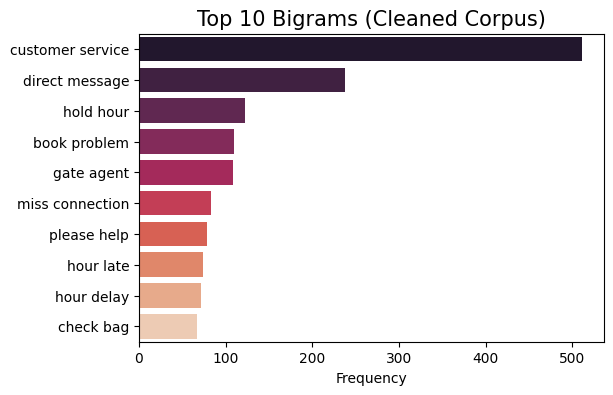

In [54]:
#Plotting Top 10 final cleaned corpus Bigrams
words, counts = zip(*top_bigrams_clean)
plt.figure(figsize=(6, 4))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="rocket", legend=False)
plt.title("Top 10 Bigrams (Cleaned Corpus)", fontsize=15)
plt.xlabel("Frequency")
plt.show()

###### Visualizing Top 10 Trigrams for till now cleaned corpus

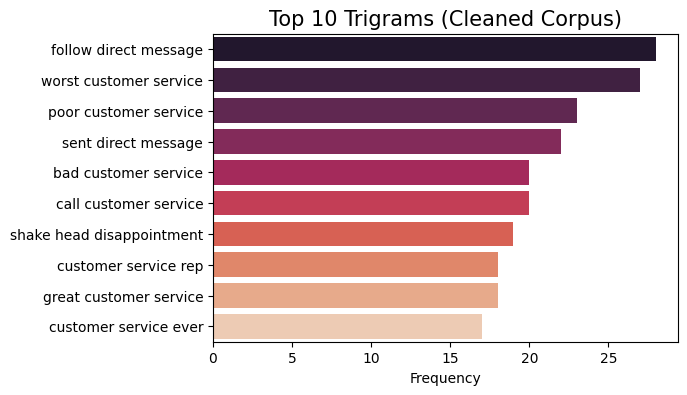

In [55]:
#Plotting Top 10 final cleaned corpus Trigrams
words, counts = zip(*top_trigrams_clean)
plt.figure(figsize=(6, 4))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette="rocket", legend=False)
plt.title("Top 10 Trigrams (Cleaned Corpus)", fontsize=15)
plt.xlabel("Frequency")
plt.show()

###### Wordcloud for till now cleaned corpus

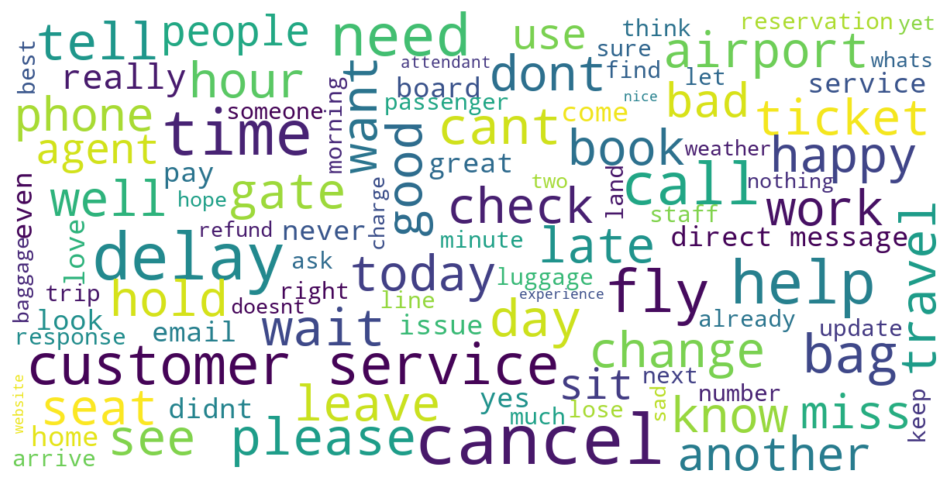

In [56]:
from wordcloud import WordCloud, STOPWORDS as wordcloud_stopwords

def show_wordcloud(data):
    #Combining the list of strings into one single string (if it not already)
    if isinstance(data, pd.Series):
        text = ' '.join(data.astype(str))
    elif isinstance(data, list):
        text = ' '.join(data)
    else:
        text = str(data)

    #Configuring the WordCloud
    wordcloud = WordCloud(
        background_color='white',
        stopwords=wordcloud_stopwords,
        max_words=100,
        max_font_size=30,
        scale=3,
        random_state=1
    )

    #Generating the word cloud
    wordcloud.generate(text)

    #Plotting the image
    fig = plt.figure(1, figsize=(12, 12))
    plt.axis('off')
    plt.imshow(wordcloud, interpolation='bilinear') 
    plt.show()

#Calling the function with the corpus
show_wordcloud(corpus)

###### Dropping not needed any more columns in dataframe

In [57]:
df_text_tweets.drop(["after_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text",
                     "after_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text",
                    "after_rare_custom_stopwords_chat_stopwords_digits_punct_lower_@_#_emojis_emoticons_translation_text",
                     "lemmatized_cleaned_text"
                    ],axis=1, inplace=True, errors='ignore')

#Checking at the moment columns
display(df_text_tweets.head())
#print(' ')
#display(df_text_tweets.sample(5))
#print(' ')
#display(df_text_tweets.tail())

,text,lemmatized_cleaned_text_final
1,@VirginAmerica plus you've added commercials to the experience... tacky.,plus added commercial experience
2,@VirginAmerica I didn't today... Must mean I need to take another trip!,didnt today must mean need another
3,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",really aggressive blast obnoxious entertainment guest little recourse
4,@VirginAmerica and it's a really big bad thing about it,really big bad thing
5,@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.\nit's really the only bad thing about flying VA,seriously pay seat didnt play really bad thing fly


###### Re-aligning final corpus with the original labels 

In [58]:
#Keeping only rows where the cleaned text of column "lemmatized_cleaned_text_final" has length greater than 0
df_text_tweets = df_text_tweets[df_text_tweets["lemmatized_cleaned_text_final"].str.strip() != ""]

#Final rows after removing empty rows in the cleaned text column "lemmatized_cleaned_text_final"
print(f"Rows after removing empty rows in finally cleaned text column: {len(df_text_tweets)}")

#Checking that both dataframes have the same index
print(f"full_df_tweets shape: {full_df_tweets.shape}")
print(f"df_text_tweets shape: {df_text_tweets.shape}")

#Re-aligning with the original labels via connection with indexes. With dropna ensuring indexes are aligned
df_final = pd.DataFrame({
    "text": df_text_tweets["lemmatized_cleaned_text_final"],  #final_corpus
    "airline_sentiment": full_df_tweets["airline_sentiment"], #labels
    "airline": full_df_tweets["airline"]                      #airline_names
}).dropna()

print(f"Model dataframe shape: {df_final.shape}")
print(f"Label distribution:\n{df_final['airline_sentiment'].value_counts()}")
print(f"Label distribution (%):\n{df_final['airline_sentiment'].value_counts(normalize=True).round(3)*100}")

#Verifying the alignment with the original labels 
print(f"Sample check:")
display(df_final.head())

#Updating corpus
corpus=df_final["text"]

#display(df_final.head())

Rows after removing empty rows in finally cleaned text column: 14185
full_df_tweets shape: (14587, 9)
df_text_tweets shape: (14185, 2)
Model dataframe shape: (14185, 3)
Label distribution:
airline_sentiment
negative    9111
neutral     2919
positive    2155
Name: count, dtype: int64
Label distribution (%):
airline_sentiment
negative    64.2
neutral     20.6
positive    15.2
Name: proportion, dtype: float64
Sample check:


,text,airline_sentiment,airline
1,plus added commercial experience,positive,Virgin America
2,didnt today must mean need another,neutral,Virgin America
3,really aggressive blast obnoxious entertainment guest little recourse,negative,Virgin America
4,really big bad thing,negative,Virgin America
5,seriously pay seat didnt play really bad thing fly,negative,Virgin America


###### Visualizing updated distribution of tweet word count

Mean Word Count: 7.00
Median Word Count: 7.00


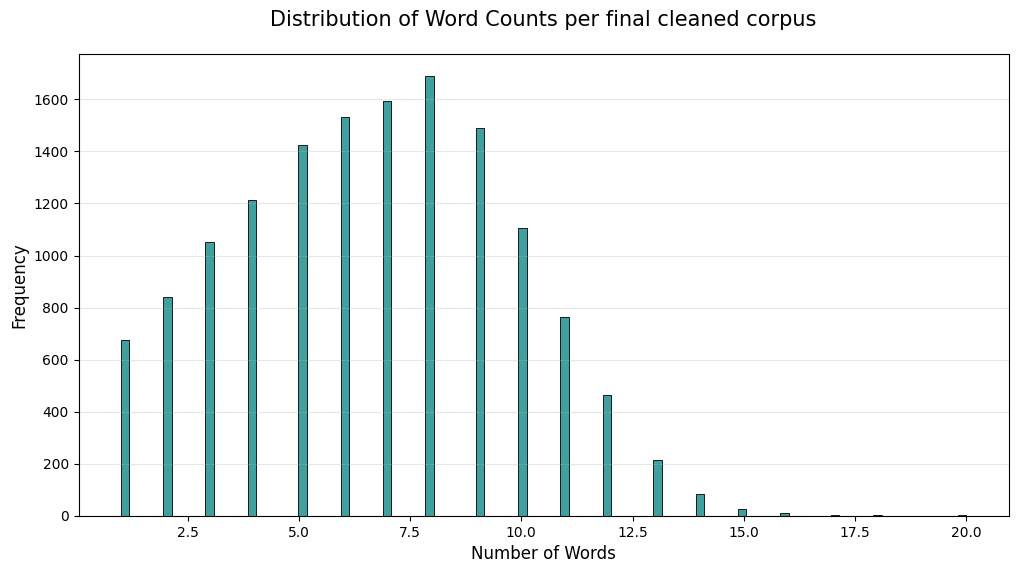

In [59]:
#Calculating updated word counts by splitting strings into lists
df_final["word_count"] = df_final["text"].str.split().str.len()

#Calculating key statistics
mean_words = df_final["word_count"].mean().round()
median_words = df_final["word_count"].median().round()

print(f"Mean Word Count: {mean_words:.2f}")
print(f"Median Word Count: {median_words:.2f}")

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df_final["word_count"], bins=100, color="teal", label="Word Count")

plt.title("Distribution of Word Counts per final cleaned corpus", fontsize=15, pad=20)
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

###### Visualizing updated Distribution of tweet character count 

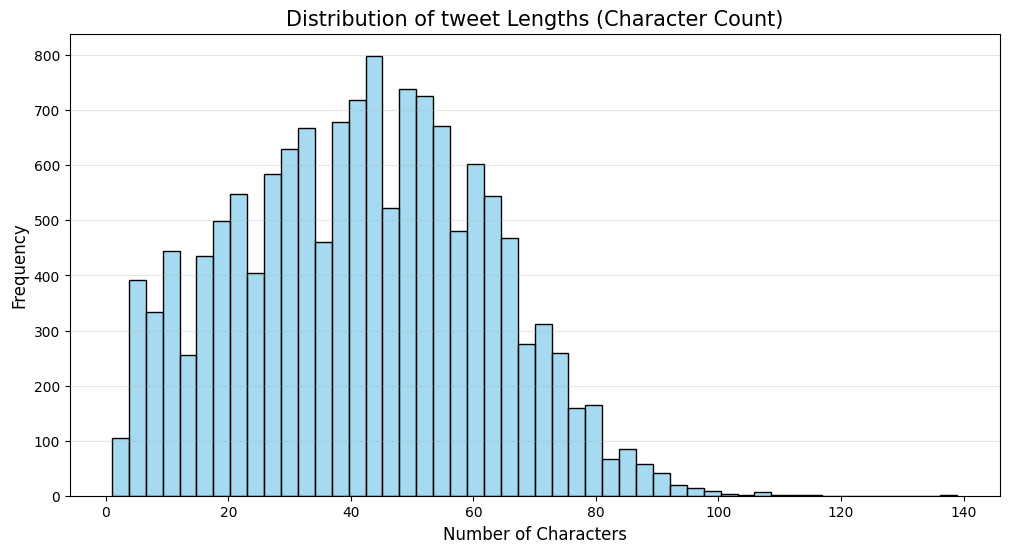

In [60]:
#Checking the number of characters present in each sentence to have a rough idea about the tweet text length
df_final["char_count"] = df_final["text"].str.len()

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df_final["char_count"], bins=50, color="skyblue")
plt.title("Distribution of tweet Lengths (Character Count)", fontsize=15)
plt.xlabel("Number of Characters", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

###### Visualizing updated average word tweet length 

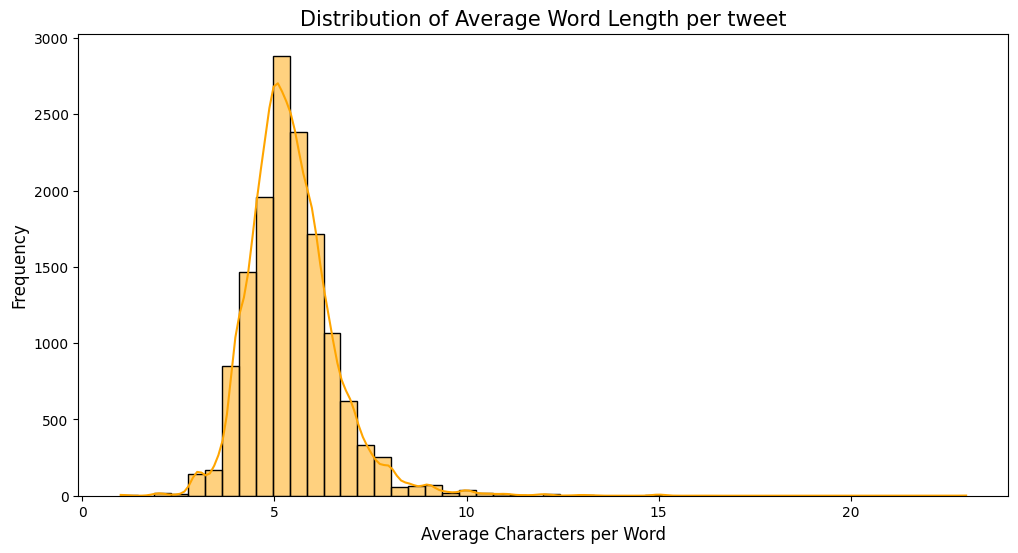

In [61]:
def get_avg_word_len(text):
    """Function to calculating average word length"""
    words = str(text).split()
    if len(words) == 0:
        return 0
    return sum(len(word) for word in words) / len(words)

df_final['avg_word_len'] = df_final['text'].apply(get_avg_word_len)

#Creating a histogram distribution plot
plt.figure(figsize=(12, 6))
sns.histplot(df_final['avg_word_len'], bins=50, kde=True, color="orange")

plt.title("Distribution of Average Word Length per tweet", fontsize=15)
plt.xlabel("Average Characters per Word", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

###### Topic Modelling for final cleaned corpus

In [62]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import pyLDAvis.lda_model

#Grabbing latest cleaned corpus
corpus = df_final["text"]

#Re-vectorizing the text 
tf_vectorizer = CountVectorizer(stop_words=None,
                                max_df=0.85,    #Ignoring words that appear in >85% of documents
                                min_df=2)       #Ignoring words that appear in less than 2 documents
    
tf = tf_vectorizer.fit_transform(corpus)

#Initializing and fitting the LDA model for 3 topics(one per sentiment) 
lda_model = LatentDirichletAllocation(n_components=3, random_state=42)
lda_model.fit(tf)

#Preparing the visualization
pyLDAvis.enable_notebook()
panel = pyLDAvis.lda_model.prepare(lda_model, tf, tf_vectorizer, mds='tsne')

#Printing top 10 words per topic
feature_names = tf_vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

#Displaying the dashboard
pyLDAvis.display(panel)

Topic 1: cancel, no, not, fly, help, dont, cant, book, direct, please
Topic 2: hour, no, delay, wait, hold, not, bag, gate, time, miss
Topic 3: customer, service, not, bad, time, great, happy, fly, experience, ever


##### LDA Topic Modelling Conclusions :

- Topic 1: cancel, no, not, fly, help, dont, cant, book, direct, please => Service Requests & Booking Complaints
  Sentiment: Negative
  
- Topic 2: hour, no, delay, wait, hold, not, bag, gate, time, miss => Operational Delays & Baggage Issues
  Sentiment: Negative

- Topic 3: customer, service, not, bad, time, great, happy, fly, experience, ever => Overall Experience Reviews
  Sentiment: Mixed Negative/Neutral

##### Insight: 

- All 3 LDA topics carry negative sentiment, consistent with the ~60% negative class distribution found earlier in EDA (negative:9.159=>62,7%,neutral:3091=>21,2%,positive:2.354=>16,1%).

- LDA captures complaint themes rather than sentiment polarity. More specifically:

1. Topic 1 captures What customers need (rebooking, help requests)
2. Topic 2 captures What went wrong operationally (delays, bags)
3. Topic 3 captures How customers felt overall (explicit reviews)

###### Dropping not needed any more columns in final dataframe

In [63]:
df_final.drop(["word_count","char_count","avg_word_len"],axis=1, inplace=True, errors='ignore')

#Checking at the moment columns of final cleaned compus
#display(df_final.head())

print("Final shape of the compus is:")
print(df_final.shape)

Final shape of the compus is:
(14185, 3)


***

#### Vectorization

###### Tokenizing the final cleaned corpus into lists of words

In [64]:
#Tokenizing the final cleaned corpus into lists of words
tokenized_corpus = [doc.split() for doc in corpus]

total_tokens = sum(len(tokens) for tokens in tokenized_corpus)
unique_tokens = len(set(token for tokens in tokenized_corpus for token in tokens))

print(f"Total documents:{len(tokenized_corpus)}")
print(f"Total tokens:{total_tokens}")
#print(f"Sample tokens: {tokenized_corpus[0][:10]}")
print(f"Unique tokens:{unique_tokens}")
print(f"Avg tokens per doc:{total_tokens / len(tokenized_corpus):.1f}")

Total documents:14185
Total tokens:94389
Unique tokens:4649
Avg tokens per doc:6.7


###### Vectorization for df_final dataframe with TD-IDF

In [65]:
#TF-IDF vectorizer is more reliable as it can capture term importance reliably at this scale (14180 × 4377)
tfidf_vectorizer = TfidfVectorizer(
    max_features  = 5000,     
    sublinear_tf  = True,      #applying log(tf) that is critical for sentiment tasks
    min_df        = 2,         #drop terms appearing in fewer than 2 docs
    max_df        = 0.95,      #drop terms appearing in >95% of docs
    ngram_range   = (1, 2)     #including bigrams 
)

#Fitting and transforming the corpus
X_final_tfidf = tfidf_vectorizer.fit_transform(corpus)

print(f"TF-IDF Matrix Shape: {X_final_tfidf.shape}")
#sparse matrix that only stores the locations and values of the non-zero element

#Only converting a small slice to dense dataframe for display:
sample_display = pd.DataFrame(
    X_final_tfidf[:5].toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
display(sample_display)

print(f"Input dim for ANN (TF-IDF vocab size): {X_final_tfidf.shape[1]}")

TF-IDF Matrix Shape: (14185, 5000)


,abc,ability,able,able change,able check,able direct,able help,able leave,able put,able reach,...,yet cant,yet customer,yet no,yet please,yet see,young,youth,yup,zero,zone
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Input dim for ANN (TF-IDF vocab size): 5000


##### Vectorization method to use :

- TF-IDF vectorizer: Choosing TF-IDF vectorizar as the most reliable, as it can capture term importance reliably with Total documents: 14185, Total tokens: 94389 & unique tokens: 4649.

- Word2Vec vectorizer & FastText vectorizer need at least 1M tokens to be efficient per bibliography search.

***

#### ANN Classifier

In [66]:
"""
ANN module for training
"""

class ANN(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, output_dim, #flow: input->hidden layer1->hidden layer2->output
                 dropout_p1=0.3, dropout_p2=0.2):
        """
        Args:
            input_dim   (int): Number of input features.
            hidden_dim1 (int): Number of units in the first hidden layer.
            hidden_dim2 (int): Number of units in the second hidden layer.
            output_dim  (int): Number of output units.
            dropout_p1  (float): Dropout probability for the first hidden layer.
            dropout_p2  (float): Dropout probability for the second hidden layer.
        """
        super(ANN, self).__init__()

        #Defining fully-connected layers:
        #First hidden layer
        self.fc1 = nn.Linear(input_dim, hidden_dim1)  
        #Second hidden layer
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2) 
        #Output layer
        self.fc3 = nn.Linear(hidden_dim2, output_dim) 

        #Defining dropout layers:
        self.dropout1 = nn.Dropout(p=dropout_p1)
        self.dropout2 = nn.Dropout(p=dropout_p2)
        
    def forward(self, x):
        """
        Forward pass through the network.
        """
        #First hidden layer with Gelu activation, then dropout & finally forming output from hidden layer1 to go to hidden layer2
        x = F.gelu(self.fc1(x))
        x = self.dropout1(x) 
        #Second hidden layer with Gelu activation, then dropout & finally forming output from hidden layer2 to go to output layer
        x = F.gelu(self.fc2(x))
        x = self.dropout2(x)
        #Output layer
        x = self.fc3(x)  
        return x
        

##### Helper Functions for the training and the validations

###### Helper Function for EarlyStopping

In [67]:
class EarlyStopping:
    """
    Early stops the training if validation loss doesn't improve after
    a given patience.
    """
    def __init__(self, patience=5, min_delta=0.0001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > (self.best_loss - self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter   = 0

###### Helper Function for plotting train losses to pdf

In [68]:
def plot_losses_to_pdf(
        train_losses,
        val_losses,
        pdf_filename='training_validation_losses.pdf',
        figsize=(8, 6),
        show_plot=False,
):
    """
    Plots the training and validation losses,
    and saves the figure to a PDF file.

    Args:
        train_losses  (list): Training loss per epoch.
        val_losses    (list): Validation loss per epoch.
        pdf_filename  (str) : Name/path of the PDF file to save.
        figsize       (tuple): Size of the figure (width, height in inches).
        show_plot     (bool) : Show the plot inline or not.
    Return:
        pdf_filename (str): The filename of the generated pdf.
    """
    fig = plt.figure(figsize=figsize)
    ax  = fig.add_subplot(1, 1, 1)

    ax.plot(train_losses, label="Train Loss")
    ax.plot(val_losses,   label="Val Loss")

    ax.set_title("Training & Validation Loss  (ANN — TF-IDF)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

    with PdfPages(pdf_filename) as pdf:
        pdf.savefig(fig)

    if show_plot:
        plt.show()

    plt.close(fig)
    print(f"The learning curves are generated in pdf: {pdf_filename}")
    return pdf_filename

###### Helper Function for creating directory for a file path if it does not exist

In [69]:
def ensure_dir_exists(file_path: str) -> None:
    """
    Create directory for a file path if it does not exist.

    Args:
        file_path (str): Full file path (including filename).
    """
    directory = os.path.dirname(file_path)
    if directory and not os.path.exists(directory):
        os.makedirs(directory, exist_ok=True)

###### Evaluation configuration function for hypermarameters

In [70]:
def evaluate_config(
    params,
    train_dataset,
    val_dataset,
    input_dim,
    output_dim,
    device,
    num_epochs,
    loss_function
):
    """
    Trains a single ANN configuration and returns its best validation metrics.
    """
    #Building DataLoaders from the param's batch_size
    train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=params['batch_size'], shuffle=False)

    #Initialising model with this trial's architecture
    model = ANN(
        input_dim   = input_dim,
        hidden_dim1 = params['hidden_dim1'],
        hidden_dim2 = params['hidden_dim2'],
        output_dim  = output_dim,
        dropout_p1  = params['dropout_p1'],
        dropout_p2  = params['dropout_p2']
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr           = params['lr'],
        weight_decay = 0.0001
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, min_lr=0.000001
    )

    early_stopping  = EarlyStopping(patience=params['patience'], min_delta=0.001)
    best_val_loss   = float('inf')
    best_val_f1     = 0.0
    best_state      = None

    for epoch in range(num_epochs):
        #Training 
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = loss_function(model(inputs), labels)
            loss.backward()
            optimizer.step()

        #Validation 
        model.eval()
        running_loss = 0.0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                running_loss += loss_function(outputs, labels).item() * inputs.size(0)
                preds = torch.max(outputs, 1)[1]
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        epoch_val_loss = running_loss / len(val_dataset)
        epoch_val_f1   = f1_score(all_labels, all_preds, average='weighted')

        scheduler.step(epoch_val_loss)

        #Tracking best state by F1
        if epoch_val_f1 > best_val_f1:
            best_val_f1  = epoch_val_f1
            best_val_loss = epoch_val_loss
            best_state   = copy.deepcopy(model.state_dict())

        early_stopping(epoch_val_loss)
        if early_stopping.early_stop:
            break

    return best_val_loss, best_val_f1, best_state

###### Main training function train_model

In [71]:
"""
Main training script for the ANN
"""

def train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        scheduler=None,
        num_epochs=200,
        device='cpu',
        patience=5,
        save_path="checkpoints/best_model.pt"
):
    """
    Trains a PyTorch model using the provided data loaders, loss function, and optimizer.
    Implements early stopping based on validation loss.

    Args:
        model (torch.nn.Module): The neural network model to train.
        train_loader (torch.utils.data.DataLoader): DataLoader for the training set.
        val_loader (torch.utils.data.DataLoader): DataLoader for the validation set.
        criterion (torch.nn.Module): Loss function to optimize (e.g., CrossEntropyLoss).
        optimizer (torch.optim.Optimizer): Optimizer for model parameters (e.g., Adam, SGD).
        scheduler (torch.optim.lr_scheduler, optional): Learning rate scheduler. If provided,
        steps on validation loss each epoch. If None, learning rate stays fixed. Defaults to None.
        num_epochs (int, optional): Maximum number of epochs to train. Defaults to 20.
        device (str, optional): Device to train on ('cpu' or 'cuda'). Defaults to 'cpu'.
        patience (int, optional): Number of epochs to wait for improvement before early stopping. Defaults to 5.
        save_path (str, optional): Path to save the best model checkpoint. Defaults to "checkpoints/best_model.pt".

    Returns:
        model (torch.nn.Module): The trained model.
        train_losses (List[float]): Training loss for each epoch.
        val_losses (List[float]): Validation loss for each epoch.
        train_accuracies (List[float]): Training accuracy for each epoch.
        val_accuracies (List[float]): Validation accuracy for each epoch.
    """
    #Initializing EarlyStopping
    early_stopping = EarlyStopping(patience=patience, min_delta=0.0001)

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    best_val_loss = float("inf")

    for epoch in range(num_epochs):
        # -----------------------
        #Training phase
        model.train()
        running_loss = 0.0
        correct_preds = 0
        total_samples = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs.float())
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            #Calculating number of correct predictions
            _, predicted = torch.max(outputs, dim=1)
            correct_preds += (predicted == labels).sum().item()
            total_samples += labels.size(0)

        #Computing average training loss and accuracy for the epoch
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct_preds / total_samples

        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)

        # -----------------------
        #Validation phase
        model.eval()
        running_val_loss = 0.0
        correct_val_preds = 0
        val_samples = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs.float())
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)

                #Accuracy for validation
                _, predicted = torch.max(outputs, dim=1)
                correct_val_preds += (predicted == labels).sum().item()
                val_samples += labels.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_acc = correct_val_preds / val_samples

        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        #Printing epoch metrics
        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | "
              f"Train Acc: {epoch_train_acc:.4f} | Val Acc: {epoch_val_acc:.4f}")

        if scheduler is not None:
            scheduler.step(epoch_val_loss)
        
        # -----------------------
        #Saving the best model
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss

            ensure_dir_exists(save_path)

            torch.save({
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": epoch_val_loss,
            }, save_path)

            print(f"✅ Model improved. Saved to {save_path}")
        # -----------------------
        #Early stopping check
        early_stopping(epoch_val_loss)
        if early_stopping.early_stop:
            print("Early stopping triggered.")
            break
            
    return model, train_losses, val_losses, train_accuracies, val_accuracies


##### Main Section of the training

Initial Data are loaded. Total length of the dataset is: 14640
Shape of X (TF-IDF): (14185, 5000)
Class weights: {'negative': np.float64(0.519), 'neutral': np.float64(1.62), 'positive': np.float64(2.194)}
The preprocessing of the DataLoaders is finished and the model is ready for training
Training on: cpu
Epoch [1/200] | Train Loss: 1.0960 | Val Loss: 1.0896 | Train Acc: 0.3365 | Val Acc: 0.6410
✅ Model improved. Saved to checkpoints/best_model.pt
Epoch [2/200] | Train Loss: 1.0748 | Val Loss: 1.0513 | Train Acc: 0.6569 | Val Acc: 0.7073
✅ Model improved. Saved to checkpoints/best_model.pt
Epoch [3/200] | Train Loss: 1.0027 | Val Loss: 0.9524 | Train Acc: 0.7410 | Val Acc: 0.6975
✅ Model improved. Saved to checkpoints/best_model.pt
Epoch [4/200] | Train Loss: 0.8712 | Val Loss: 0.8388 | Train Acc: 0.7273 | Val Acc: 0.6982
✅ Model improved. Saved to checkpoints/best_model.pt
Epoch [5/200] | Train Loss: 0.7531 | Val Loss: 0.7845 | Train Acc: 0.7445 | Val Acc: 0.7087
✅ Model improved. Sav

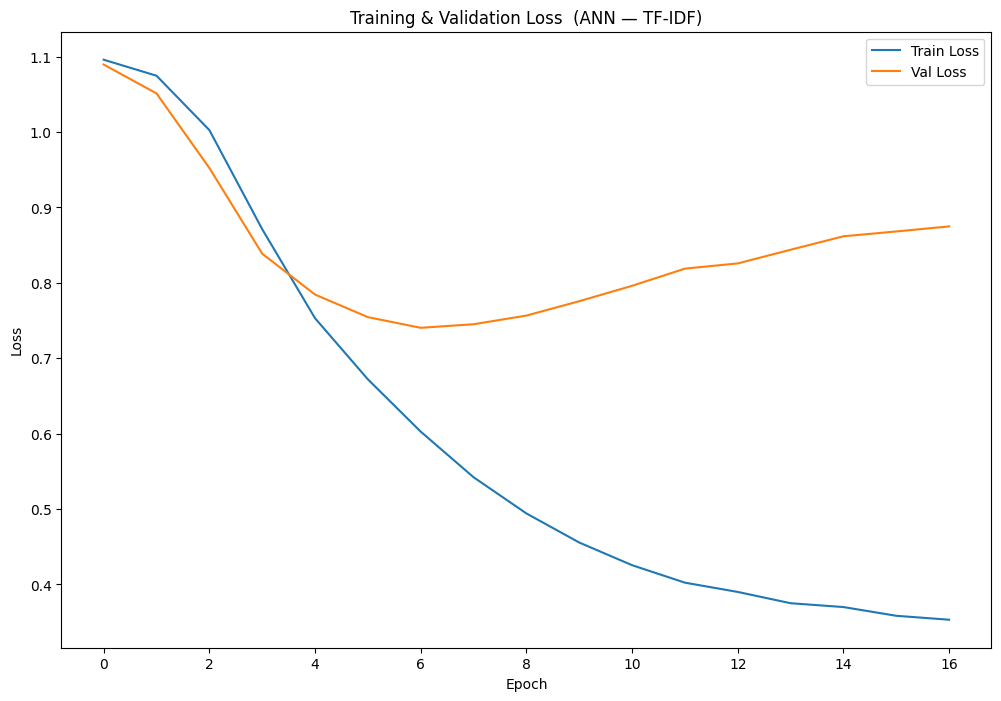

The learning curves are generated in pdf: training_validation_losses.pdf
Test Accuracy:  69.98%
Test Precision: 73.60%
Test Recall:    69.98%
Test F1:        71.31%
Confusion Matrix:
[[701 165  45]
 [ 58 166  68]
 [ 34  56 126]]
Detailed Report:
              precision    recall  f1-score   support

    negative       0.88      0.77      0.82       911
     neutral       0.43      0.57      0.49       292
    positive       0.53      0.58      0.55       216

    accuracy                           0.70      1419
   macro avg       0.61      0.64      0.62      1419
weighted avg       0.74      0.70      0.71      1419



In [72]:
#Loading original dataset without any preprocessing 
df_init = pd.read_csv(r"../data/Tweets.csv", encoding='latin-1')
print(f"Initial Data are loaded. Total length of the dataset is: {len(df_init)}")

#===================================================

#After pre-processing and text EDA dataset
df_final.head()

# ---------------------------------------------------
#Encoding sentiment labels from text to numeric values
le_ann = LabelEncoder()
df_final["Label"] = le_ann.fit_transform(df_final["airline_sentiment"])
labels = df_final["Label"].values

# ---------------------------------------------------
# 2.Setting ANN's parameters
# ---------------------------------------------------

params = {
    'lr':           0.001,
    'weight_decay': 0.0001,
    'hidden_dim1':  64,     
    'hidden_dim2':  32,
    'dropout_p1':   0.1,
    'dropout_p2':   0.4,
    'batch_size':   512,
    'patience':     10
}

# ---------------------------------------------------
#Vectorization of the sentences with tfidf
X = X_final_tfidf.toarray() if issparse(X_final_tfidf) else X_final_tfidf
print(f"Shape of X (TF-IDF): {X.shape}")

# ---------------------------------------------------
#Train / Val / Test split  (80 / 10 / 10)

#First, splitting off 20% as a temporary set 
train_X, temp_X, train_y, temp_y = train_test_split(
    X,
    labels,
    test_size=0.2,    #20% goes to temp set
    random_state=42,  #for reproducibility
    stratify=labels   #to preserve the overall class distribution
)

#Now splitting 'temp' into 10% validation and 10% test
val_X, test_X, val_y, test_y = train_test_split(
    temp_X,
    temp_y,
    test_size=0.5,    # half of the 20%
    random_state=42,  # for reproducibility
    stratify=temp_y   # preserves the distribution
)
del temp_X, temp_y

# ---------------------------------------------------
#Computing class weights for the imbalance of ~60% negative / ~20% neutral / ~20% positive

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_y),
    y=train_y
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
print(f"Class weights: {dict(zip(le_ann.classes_, class_weights.round(3)))}")

# ---------------------------------------------------
#Tensors & DataLoaders
train_X_tensor = torch.tensor(train_X, dtype=torch.float32)
train_y_tensor = torch.tensor(train_y, dtype=torch.long)

val_X_tensor   = torch.tensor(val_X,   dtype=torch.float32)
val_y_tensor   = torch.tensor(val_y,   dtype=torch.long)

test_X_tensor  = torch.tensor(test_X,  dtype=torch.float32)
test_y_tensor  = torch.tensor(test_y,  dtype=torch.long)


#Creating TensorDatasets
train_dataset = TensorDataset(train_X_tensor, train_y_tensor)
val_dataset   = TensorDataset(val_X_tensor,   val_y_tensor)
test_dataset  = TensorDataset(test_X_tensor,  test_y_tensor)

#Creating DataLoaders
train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=params['batch_size'], shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=params['batch_size'], shuffle=False)
print('The preprocessing of the DataLoaders is finished and the model is ready for training')

# ---------------------------------------------------
#Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Training on: {device}')

#Moving class weights tensor to same device as model
class_weights_tensor = class_weights_tensor.to(device)

# ---------------------------------------------------
#Initializing the model, criterion, optimizer
input_dim = X.shape[1]            #number of TF-IDF input features
output_dim = len(le_ann.classes_) #the three sentiment classes

model = ANN(
    input_dim,
    hidden_dim1 = params['hidden_dim1'],
    hidden_dim2 = params['hidden_dim2'],
    output_dim  = output_dim,
    dropout_p1  = params['dropout_p1'],
    dropout_p2  = params['dropout_p2']
).to(device)

#Loss function: weighted CrossEntropyLoss for single label multi-class classification
loss_function = nn.CrossEntropyLoss(weight=class_weights_tensor)

#Optimizer: the gradient descent algorithm, Adam
optimizer = torch.optim.Adam(model.parameters(),lr= params['lr'],weight_decay = params['weight_decay'])

# ---------------------------------------------------
#Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)
# ---------------------------------------------------

#10.Training the model (with early stopping)
num_epochs = 200

model, train_losses, val_losses, _, _ = train_model(
    model        = model,
    train_loader = train_loader,
    val_loader   = val_loader,
    criterion    = loss_function,
    optimizer    = optimizer,
    scheduler    = scheduler,
    num_epochs   = num_epochs,
    device       = device,
    patience     = params['patience']
)

checkpoint = torch.load("checkpoints/best_model.pt", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# ---------------------------------------------------
#11. Plotting training and validation losses
plot_losses_to_pdf(
    train_losses = train_losses,
    val_losses   = val_losses,
    pdf_filename = "training_validation_losses.pdf",
    figsize      = (12, 8),
    show_plot    = True
)

# ---------------------------------------------------
#12. Evaluating on the test set
model.eval()
predictions_list_test = []
labels_list_test      = []

with torch.no_grad():
    for inputs, batch_labels in test_loader:
        inputs, batch_labels = inputs.to(device), batch_labels.to(device)
        outputs   = model(inputs.float())
        _, predicted = torch.max(outputs, 1)
        predictions_list_test.extend(predicted.cpu().numpy())
        labels_list_test.extend(batch_labels.cpu().numpy())

accuracy = accuracy_score(labels_list_test, predictions_list_test) * 100
print(f"Test Accuracy:  {accuracy:.2f}%")
print(f"Test Precision: {precision_score(labels_list_test, predictions_list_test, average='weighted'):.2%}")
print(f"Test Recall:    {recall_score(labels_list_test, predictions_list_test, average='weighted'):.2%}")
print(f"Test F1:        {f1_score(labels_list_test, predictions_list_test, average='weighted'):.2%}")
print(f"Confusion Matrix:\n{confusion_matrix(labels_list_test, predictions_list_test)}")
print(f"Detailed Report:\n{classification_report(labels_list_test, predictions_list_test, target_names=le_ann.classes_)}")

##### Optimizing Hyperparameters

###### First Run with Random Search to get best parameters

In [73]:
#Seeding for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

#Random Search

RANDOM_SEARCH_SPACE = {
    'lr':          [1e-2, 5e-3, 1e-3, 5e-4, 1e-4],
    'weight_decay':[1e-2, 1e-3, 1e-4, 1e-5],
    'hidden_dim1': [16, 32 ,64, 128, 256, 512],
    'hidden_dim2': [16, 32, 64, 128, 256],
    'dropout_p1':  [0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
    'dropout_p2':  [0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
    'batch_size':  [16, 32, 64, 128, 256],
    'patience':    [5, 7, 10, 12]
}

N_RANDOM_TRIALS = 50   
NUM_EPOCHS      = 50   

print("=" * 60)
print("RANDOM SEARCH")
print(f"Running {N_RANDOM_TRIALS} random trials, max {NUM_EPOCHS} epochs each")
print("=" * 60)

random_results = []

for trial in range(N_RANDOM_TRIALS):
    #Sampling one random combination
    trial_params = {k: random.choice(v) for k, v in RANDOM_SEARCH_SPACE.items()}
    print(f"\nTrial {trial+1}/{N_RANDOM_TRIALS} | Params: {trial_params}")

    best_val_loss, best_val_f1, _ = evaluate_config(
        params        = trial_params,
        train_dataset = train_dataset,
        val_dataset   = val_dataset,
        input_dim     = input_dim,
        output_dim    = output_dim,
        device        = device,
        num_epochs    = NUM_EPOCHS,
        loss_function = loss_function
    )

    random_results.append({
        'params':       trial_params,
        'val_loss':     best_val_loss,
        'val_f1':       best_val_f1
    })

    print(f"  → Val Loss: {best_val_loss:.4f} | Val F1: {best_val_f1:.4f}")

#Sorting by best val F1
random_results.sort(key=lambda x: x['val_f1'], reverse=True)

print("\n" + "=" * 60)
print("RANDOM SEARCH — TOP 5 RESULTS")
print("=" * 60)
for i, r in enumerate(random_results[:5]):
    print(f"Rank {i+1} | Val F1: {r['val_f1']:.4f} | Val Loss: {r['val_loss']:.4f}")
    print(f"         Params: {r['params']}")

best_random_params = random_results[0]['params']
print(f"\n✅ Best random params: {best_random_params}")

RANDOM SEARCH
Running 50 random trials, max 50 epochs each

Trial 1/50 | Params: {'lr': 0.01, 'weight_decay': 0.01, 'hidden_dim1': 512, 'hidden_dim2': 64, 'dropout_p1': 0.2, 'dropout_p2': 0.2, 'batch_size': 32, 'patience': 5}
  → Val Loss: 0.7763 | Val F1: 0.7314

Trial 2/50 | Params: {'lr': 0.0001, 'weight_decay': 0.01, 'hidden_dim1': 256, 'hidden_dim2': 128, 'dropout_p1': 0.1, 'dropout_p2': 0.1, 'batch_size': 16, 'patience': 7}
  → Val Loss: 0.8333 | Val F1: 0.7500

Trial 3/50 | Params: {'lr': 0.005, 'weight_decay': 0.01, 'hidden_dim1': 256, 'hidden_dim2': 32, 'dropout_p1': 0.6, 'dropout_p2': 0.6, 'batch_size': 256, 'patience': 12}
  → Val Loss: 0.9367 | Val F1: 0.7381

Trial 4/50 | Params: {'lr': 0.005, 'weight_decay': 1e-05, 'hidden_dim1': 256, 'hidden_dim2': 64, 'dropout_p1': 0.1, 'dropout_p2': 0.2, 'batch_size': 128, 'patience': 10}
  → Val Loss: 0.7285 | Val F1: 0.7263

Trial 5/50 | Params: {'lr': 0.001, 'weight_decay': 0.001, 'hidden_dim1': 32, 'hidden_dim2': 64, 'dropout_p1': 

###### Second Run with Grid Search with best parameters from Random Search to dive deeper for optimizing more the hyperparameters

In [74]:
#Grid Search

def make_neighbors(value, choices):
    """Returns value plus its immediate neighbors in the choices list."""
    idx = choices.index(value) if value in choices else 0
    neighbors = set()
    neighbors.add(choices[idx])
    if idx > 0:
        neighbors.add(choices[idx - 1])
    if idx < len(choices) - 1:
        neighbors.add(choices[idx + 1])
    return sorted(neighbors)

#Building a tight grid around the best random result
GRID_SEARCH_SPACE = {
    'lr':          make_neighbors(best_random_params['lr'],          RANDOM_SEARCH_SPACE['lr']),
    'weight_decay':make_neighbors(best_random_params['weight_decay'],RANDOM_SEARCH_SPACE['weight_decay']),
    'hidden_dim1': make_neighbors(best_random_params['hidden_dim1'], RANDOM_SEARCH_SPACE['hidden_dim1']),
    'hidden_dim2': make_neighbors(best_random_params['hidden_dim2'], RANDOM_SEARCH_SPACE['hidden_dim2']),
    'dropout_p1':  make_neighbors(best_random_params['dropout_p1'],  RANDOM_SEARCH_SPACE['dropout_p1']),
    'dropout_p2':  make_neighbors(best_random_params['dropout_p2'],  RANDOM_SEARCH_SPACE['dropout_p2']),
    'batch_size':  make_neighbors(best_random_params['batch_size'],  RANDOM_SEARCH_SPACE['batch_size']),
    'patience':    [best_random_params['patience']]  
}

#Computing total combinations
total_combinations = 1
for v in GRID_SEARCH_SPACE.values():
    total_combinations *= len(v)

print("\n" + "=" * 60)
print("GRID SEARCH")
print(f"Grid combinations to evaluate: {total_combinations}")
print(f"Grid space: {GRID_SEARCH_SPACE}")
print("=" * 60)

grid_results = []
keys   = list(GRID_SEARCH_SPACE.keys())
values = list(GRID_SEARCH_SPACE.values())

for combo_idx, combo in enumerate(itertools.product(*values)):
    grid_params = dict(zip(keys, combo))
    print(f"\nCombo {combo_idx+1}/{total_combinations} | Params: {grid_params}")

    best_val_loss, best_val_f1, best_state = evaluate_config(
        params        = grid_params,
        train_dataset = train_dataset,
        val_dataset   = val_dataset,
        input_dim     = input_dim,
        output_dim    = output_dim,
        device        = device,
        num_epochs    = NUM_EPOCHS,
        loss_function = loss_function
    )

    grid_results.append({
        'params':      grid_params,
        'val_loss':    best_val_loss,
        'val_f1':      best_val_f1,
        'best_state':  best_state
    })

    print(f"  → Val Loss: {best_val_loss:.4f} | Val F1: {best_val_f1:.4f}")

#Sorting by best val F1
grid_results.sort(key=lambda x: x['val_f1'], reverse=True)

print("\n" + "=" * 60)
print("GRID SEARCH — TOP 5 RESULTS")
print("=" * 60)
for i, r in enumerate(grid_results[:5]):
    print(f"Rank {i+1} | Val F1: {r['val_f1']:.4f} | Val Loss: {r['val_loss']:.4f}")
    print(f"         Params: {r['params']}")

best_grid_params = grid_results[0]['params']
best_grid_state  = grid_results[0]['best_state']
print(f"\n FINAL BEST PARAMS: {best_grid_params}")


GRID SEARCH
Grid combinations to evaluate: 648
Grid space: {'lr': [0.0001, 0.0005], 'weight_decay': [1e-05, 0.0001, 0.001], 'hidden_dim1': [32, 64, 128], 'hidden_dim2': [16, 32, 64], 'dropout_p1': [0.5, 0.6], 'dropout_p2': [0.5, 0.6], 'batch_size': [32, 64, 128], 'patience': [7]}

Combo 1/648 | Params: {'lr': 0.0001, 'weight_decay': 1e-05, 'hidden_dim1': 32, 'hidden_dim2': 16, 'dropout_p1': 0.5, 'dropout_p2': 0.5, 'batch_size': 32, 'patience': 7}
  → Val Loss: 0.7516 | Val F1: 0.7433

Combo 2/648 | Params: {'lr': 0.0001, 'weight_decay': 1e-05, 'hidden_dim1': 32, 'hidden_dim2': 16, 'dropout_p1': 0.5, 'dropout_p2': 0.5, 'batch_size': 64, 'patience': 7}
  → Val Loss: 0.8142 | Val F1: 0.7483

Combo 3/648 | Params: {'lr': 0.0001, 'weight_decay': 1e-05, 'hidden_dim1': 32, 'hidden_dim2': 16, 'dropout_p1': 0.5, 'dropout_p2': 0.5, 'batch_size': 128, 'patience': 7}
  → Val Loss: 0.7390 | Val F1: 0.7461

Combo 4/648 | Params: {'lr': 0.0001, 'weight_decay': 1e-05, 'hidden_dim1': 32, 'hidden_dim2'

###### Re-training final model with optimal found parameters after tuning


------------------------------------------------------------
FINAL TRAINING with best params
------------------------------------------------------------
Epoch [1/200] | Train Loss: 1.1022 | Val Loss: 1.1006 | Train Acc: 0.6423 | Val Acc: 0.6425
✅ Model improved. Saved to checkpoints/best_tuned_model.pt
Epoch [2/200] | Train Loss: 1.0998 | Val Loss: 1.0979 | Train Acc: 0.6407 | Val Acc: 0.6425
✅ Model improved. Saved to checkpoints/best_tuned_model.pt
Epoch [3/200] | Train Loss: 1.0961 | Val Loss: 1.0936 | Train Acc: 0.6369 | Val Acc: 0.6425
✅ Model improved. Saved to checkpoints/best_tuned_model.pt
Epoch [4/200] | Train Loss: 1.0903 | Val Loss: 1.0861 | Train Acc: 0.6368 | Val Acc: 0.6474
✅ Model improved. Saved to checkpoints/best_tuned_model.pt
Epoch [5/200] | Train Loss: 1.0790 | Val Loss: 1.0722 | Train Acc: 0.6617 | Val Acc: 0.7355
✅ Model improved. Saved to checkpoints/best_tuned_model.pt
Epoch [6/200] | Train Loss: 1.0581 | Val Loss: 1.0477 | Train Acc: 0.6944 | Val Acc: 0.751

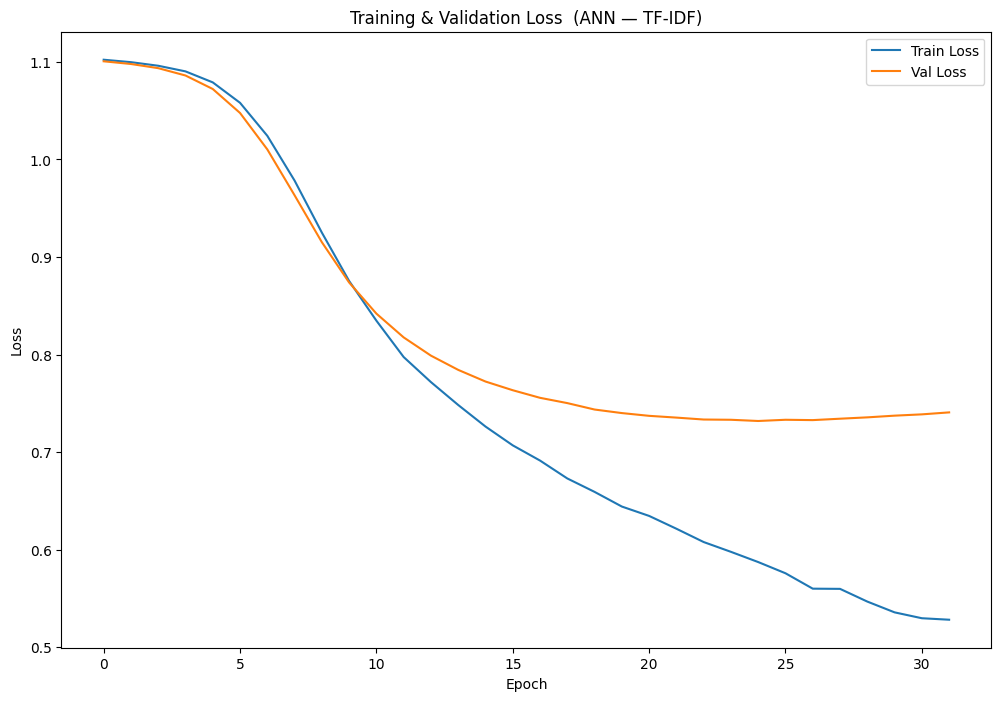

The learning curves are generated in pdf: tuned_training_validation_losses.pdf

------------------------------------------------------------
TUNED MODEL — FINAL TEST RESULTS
------------------------------------------------------------
Test Accuracy:  71.11%
Test Precision: 74.22%
Test Recall:    71.11%
Test F1:        72.29%
Detailed Report:
              precision    recall  f1-score   support

    negative       0.89      0.78      0.83       911
     neutral       0.44      0.57      0.50       292
    positive       0.53      0.60      0.56       216

    accuracy                           0.71      1419
   macro avg       0.62      0.65      0.63      1419
weighted avg       0.74      0.71      0.72      1419

Confusion Matrix:
[[715 151  45]
 [ 59 165  68]
 [ 32  55 129]]


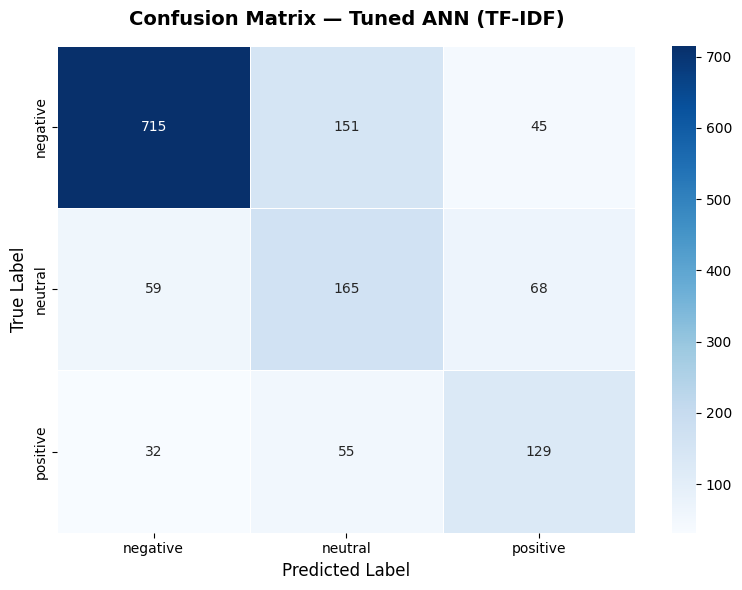

In [75]:
#Final model results
print("\n" + "-" * 60)
print("FINAL TRAINING with best params")
print("-" * 60)

final_model = ANN(
    input_dim,
    hidden_dim1 = best_grid_params['hidden_dim1'],
    hidden_dim2 = best_grid_params['hidden_dim2'],
    output_dim  = output_dim,
    dropout_p1  = best_grid_params['dropout_p1'],
    dropout_p2  = best_grid_params['dropout_p2']
).to(device)

final_optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr           = best_grid_params['lr'],
    weight_decay = best_grid_params['weight_decay']
)

final_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    final_optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)

final_train_loader = DataLoader(
    train_dataset, batch_size=best_grid_params['batch_size'], shuffle=True
)
final_val_loader = DataLoader(
    val_dataset, batch_size=best_grid_params['batch_size'], shuffle=False
)

final_model, train_losses, val_losses, _, _ = train_model(
    model        = final_model,
    train_loader = final_train_loader,
    val_loader   = final_val_loader,
    criterion    = loss_function,
    optimizer    = final_optimizer,
    scheduler    = final_scheduler,   
    num_epochs   = 200,
    device       = device,
    patience     = best_grid_params['patience'],
    save_path    = "checkpoints/best_tuned_model.pt"
)

#Plotting final curves
plot_losses_to_pdf(
    train_losses = train_losses,
    val_losses   = val_losses,
    pdf_filename = "tuned_training_validation_losses.pdf",
    figsize      = (12, 8),
    show_plot    = True
)

# ---------------------------------------------------
#Evaluating tuned model on test set
checkpoint = torch.load("checkpoints/best_tuned_model.pt", map_location=device)
final_model.load_state_dict(checkpoint["model_state_dict"])
final_model.eval()

predictions_list_test = []
labels_list_test      = []

with torch.no_grad():
    for inputs, batch_labels in test_loader:
        inputs, batch_labels = inputs.to(device), batch_labels.to(device)
        outputs = final_model(inputs.float())
        _, predicted = torch.max(outputs, 1)
        predictions_list_test.extend(predicted.cpu().numpy())
        labels_list_test.extend(batch_labels.cpu().numpy())

print("\n" + "-" * 60)
print("TUNED MODEL — FINAL TEST RESULTS")
print("-" * 60)
print(f"Test Accuracy:  {accuracy_score(labels_list_test, predictions_list_test)*100:.2f}%")
print(f"Test Precision: {precision_score(labels_list_test, predictions_list_test, average='weighted'):.2%}")
print(f"Test Recall:    {recall_score(labels_list_test, predictions_list_test, average='weighted'):.2%}")
print(f"Test F1:        {f1_score(labels_list_test, predictions_list_test, average='weighted'):.2%}")
print(f"Detailed Report:\n{classification_report(labels_list_test, predictions_list_test, target_names=le_ann.classes_)}")
print(f"Confusion Matrix:\n{confusion_matrix(labels_list_test, predictions_list_test)}")

#Plotting confusion matrix
confusion_matrix = confusion_matrix(labels_list_test, predictions_list_test)
plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le_ann.classes_,
    yticklabels=le_ann.classes_,
    linewidths=0.5
)

plt.title('Confusion Matrix — Tuned ANN (TF-IDF)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

##### Conclusion on final tuned Model:

- Negative Class: Model handles negative sentiment well, achieving the strongest performance across all classes (F1: 0.83). This is expected as negative tweets dominate the training data (~60%) and use distinctive, unambiguous language. 715 out of 911 negatives are correctly classified.

- Neutral Class: Model struggles to identify the neutral class as it shares vocabulary with both other classes, making TF-IDF work harder. Only 165 out of 292 neutrals are correctly classified (F1: 0.50).

- Positive Class: Model struggles to identify the boundary between "slightly positive" and "neutral", since per confusion matrix 55 positives are misclassified as neutral. 129 out of 216 positives are correctly classified (F1: 0.56).